In [1]:
import json
import numpy as np
import pandas as pd
import scipy.signal as sig
import h5py
import os 
import matplotlib.pyplot as plt
import math 
from scipy import signal, stats
from scipy.fft import fft, fftfreq

In [2]:
from wsl_permission_manager import grant_universal_read_write_access, grant_universal_directory_access, set_path_permissions

# Your WSL path (make sure this is correct, including any spaces!)
# For a specific file like 'classes-fixed.json':
my_wsl_file_path_classes = r"\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json"
my_wsl_file_path_dataset = r"\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\GOLD_XYZ_OSC.0001_1024.hdf5"

# For the directory containing it:
my_wsl_directory_path = r"\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2"

# --- Option 1: Grant rw-rw-rw- (0o666) to a specific file ---
print(f"Setting permissions for file: {my_wsl_file_path_classes}")
success_file = grant_universal_read_write_access(my_wsl_file_path_classes)
if success_file:
    print(f"Successfully granted read/write access to: {my_wsl_file_path_classes}")
    # Now try your file operation again
    # with open(my_wsl_file_path_classes, 'r') as f:
    #     content = f.read() # Or json.load(f)
    #     print("Successfully read file after permission change.")
else:
    print(f"Failed to set permissions for: {my_wsl_file_path_classes}")

print("-" * 30)

# --- Option 2: Grant rwxrwxrwx (0o777) to a directory ---
# (Use this if you need to list, create, or delete files within this directory)
print(f"Setting permissions for directory: {my_wsl_directory_path}")
success_dir = grant_universal_directory_access(my_wsl_directory_path)
if success_dir:
    print(f"Successfully granted full access to directory: {my_wsl_directory_path}")
    # import os
    # print(os.listdir(my_wsl_directory_path))
else:
    print(f"Failed to set permissions for directory: {my_wsl_directory_path}")

print("-" * 30)

Setting permissions for file: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json
Attempting to set permissions for: '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json' to 0o666
Successfully set permissions for '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json' to 0o666.
Successfully granted read/write access to: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json
------------------------------
Setting permissions for directory: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2
Attempting to set permissions for: '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2' to 0o777
Successfully set permissions for '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2' to 0o777.
Successfully granted full access to directory: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_

In [3]:
X_arr = None
Y_arr = None # Inisialisasi variabel
Z_arr = None # Inisialisasi variabel

# Sel 2: Membuka file HDF5 dan membaca data
print(f"Mencoba membuka file: {my_wsl_file_path_dataset}")
if not os.path.exists(my_wsl_file_path_dataset):
    print(f"Error: File tidak ditemukan di {my_wsl_file_path_dataset}")
else:
    try:
        # Menggunakan locking=False langsung di sini
        with h5py.File(my_wsl_file_path_dataset, 'r', locking=False) as f:
            print("File HDF5 berhasil dibuka (tanpa penguncian).")
            Y_arr = f['Y'][:]            # shape (2555904, 24) jika mengikuti error awalmu
            Z_arr = f['Z'][:].flatten()  # shape (2555904,) jika mengikuti error awalmu
            print("Data berhasil dibaca.")
            # Kamu bisa langsung memproses Y_arr dan Z_arr di sini atau di sel berikutnya
            
    except BlockingIOError as e:
        print(f"Masih terjadi BlockingIOError meskipun menggunakan locking=False: {e}")
        print("Ini bisa mengindikasikan masalah yang lebih dalam dengan akses file atau file itu sendiri.")
    except KeyError as e:
        print(f"Error: Dataset tidak ditemukan di file HDF5: {e}. Pastikan nama dataset ('Y' atau 'Z') sudah benar.")
    except Exception as e:
        print(f"Terjadi error tak terduga saat membuka atau membaca file HDF5: {e}")

# Sel 3 (Opsional): Bekerja dengan data yang sudah dibaca
if Y_arr is not None and Z_arr is not None:
    print("\nMemeriksa data yang sudah dibaca:")
    print(f"Bentuk Y_arr: {Y_arr.shape}")
    print(f"Bentuk Z_arr: {Z_arr.shape}")
    # Lakukan operasi lain dengan Y_arr dan Z_arr
else:
    print("\nData tidak berhasil dibaca, tidak ada yang bisa diproses.")

Mencoba membuka file: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\GOLD_XYZ_OSC.0001_1024.hdf5
File HDF5 berhasil dibuka (tanpa penguncian).
Data berhasil dibaca.

Memeriksa data yang sudah dibaca:
Bentuk Y_arr: (2555904, 24)
Bentuk Z_arr: (2555904,)


In [4]:
with open(my_wsl_file_path_classes, 'r') as f:
    fixed_classes = json.load(f)

print(f"Found {len(fixed_classes)} modulations:\n", fixed_classes)

Found 24 modulations:
 ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [5]:
# Coba cek apakah file ada
if not os.path.exists(my_wsl_file_path_dataset):
    print(f"Error: File tidak ditemukan di {my_wsl_file_path_dataset}")
else:
    print(f"File ditemukan di {my_wsl_file_path_dataset}. Mencoba membuka...")
    try:
        with h5py.File(my_wsl_file_path_dataset, 'r', locking=False) as f:
            print("File berhasil dibuka!")
            #Baris kode asli kamu untuk membaca data
            Y_arr = f['Y'][:]
            Z_arr = f['Z'][:].flatten()
            print("Data Y_arr shape:", Y_arr.shape)
            print("Data Z_arr shape:", Z_arr.shape)
            print("Silakan uncomment baris untuk membaca data jika file berhasil dibuka.")
    except BlockingIOError as e:
        print(f"Masih terjadi BlockingIOError: {e}")
    except Exception as e:
        print(f"Terjadi error lain: {e}")

File ditemukan di \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\GOLD_XYZ_OSC.0001_1024.hdf5. Mencoba membuka...
File berhasil dibuka!
Data Y_arr shape: (2555904, 24)
Data Z_arr shape: (2555904,)
Silakan uncomment baris untuk membaca data jika file berhasil dibuka.


In [6]:
unique_snrs = np.unique(Z_arr)
print("Available SNR levels (dB):", unique_snrs)

Available SNR levels (dB): [-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]


In [7]:
def find_modulation_snr_indices(mod_name, snr_level, classes_fixed, Y_arr, Z_arr):
    """
    Return an array of sample-indices where:
      - the one-hot in Y_arr matches mod_name
      - the corresponding Z_arr == snr_level
    """
    mod_idx = classes_fixed.index(mod_name)
    mask = (np.argmax(Y_arr, axis=1) == mod_idx) & (Z_arr == snr_level)
    return np.nonzero(mask)[0]

In [8]:
def plot_signals_by_modulation_snr(mod_name, snr_level, num_samples, file_path, classes_fixed, Y_arr, Z_arr):
    # 1) find indices
    idxs = find_modulation_snr_indices(mod_name, snr_level, classes_fixed, Y_arr, Z_arr)
    if len(idxs) < num_samples:
        print(f"⚠️ Only found {len(idxs)} samples for {mod_name}@{snr_level} dB")
        return

    # 2) pick a few at random
    chosen = np.random.choice(idxs, num_samples, replace=False)

    # 3) re-open HDF5 and slice X for each sample
    with h5py.File(file_path, 'r',locking=False) as f:
        X_ds = f['X']  # shape (N, 1024, 2)
        for samp in chosen:
            I = X_ds[samp, :, 0]
            Q = X_ds[samp, :, 1]
            M = np.sqrt(I**2 + Q**2)

            fig, axs = plt.subplots(1, 3, figsize=(15, 3))
            axs[0].plot(I); axs[0].set_title(f"{mod_name} I (SNR={snr_level}dB)")
            axs[1].plot(Q); axs[1].set_title(f"{mod_name} Q")
            axs[2].plot(M); axs[2].set_title("Magnitude")
            for ax in axs:
                ax.set_xlabel("Sample index")
            plt.tight_layout()
            plt.show()

In [9]:
with h5py.File(my_wsl_file_path_dataset, 'r', locking=False) as f:
    Y_onehot = f['Y'][:]    # one-hot label array, shape (N_samples, N_mods)
    Z_arr     = f['Z'][:].flatten()  # SNRs

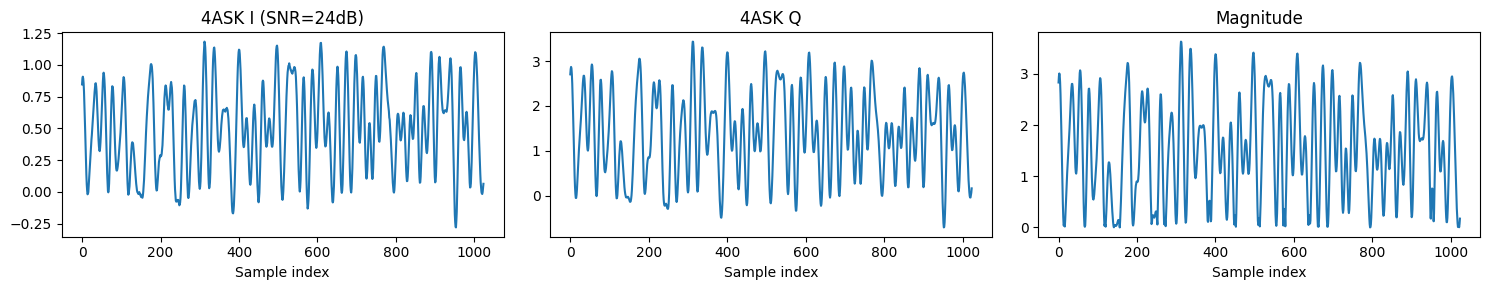

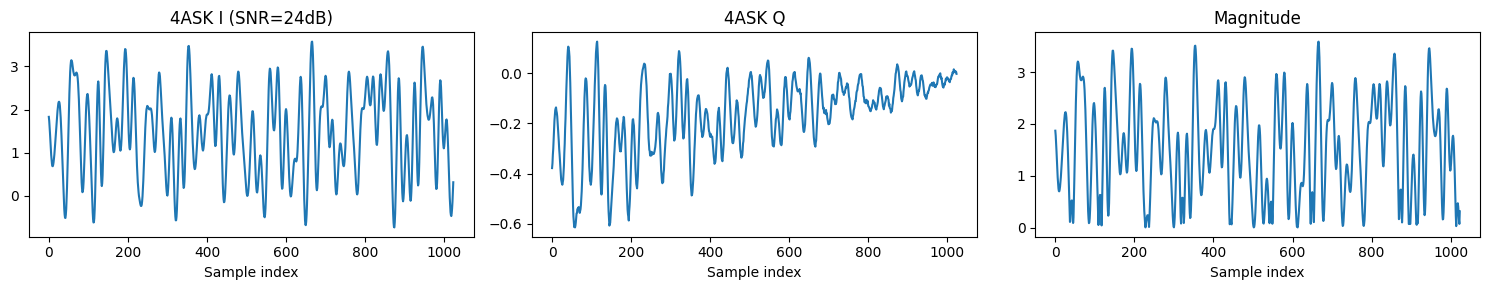

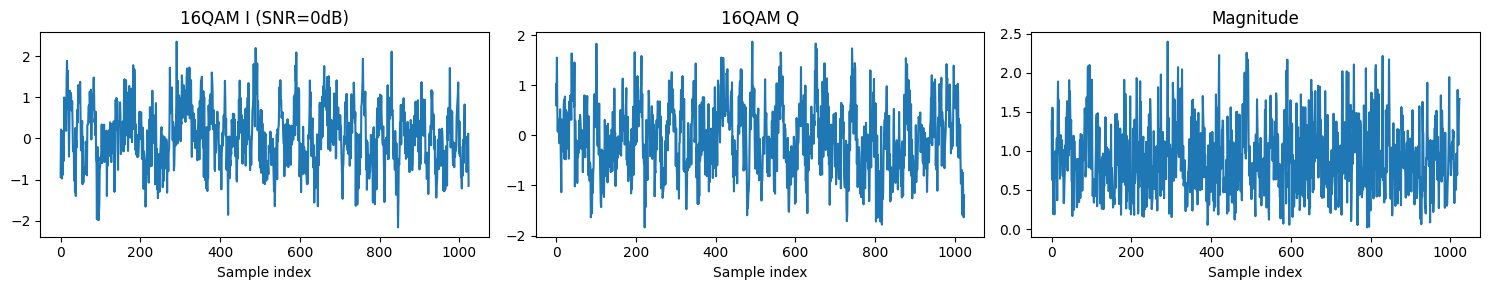

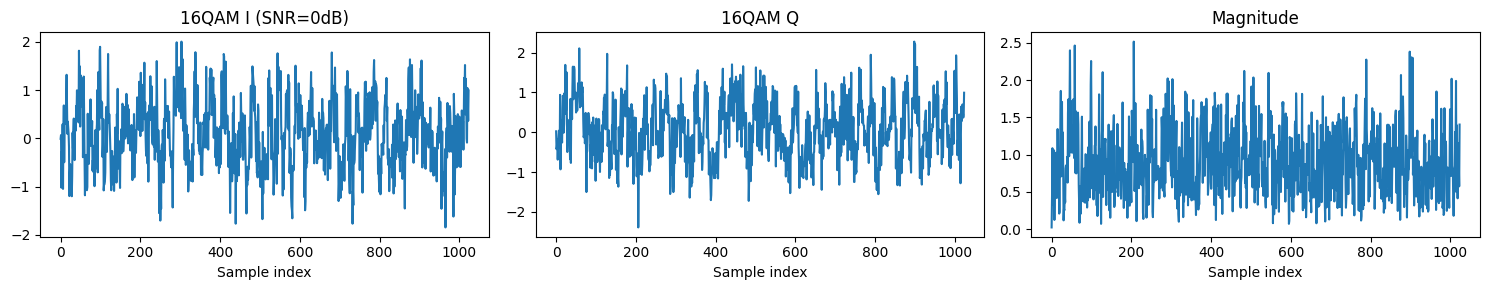

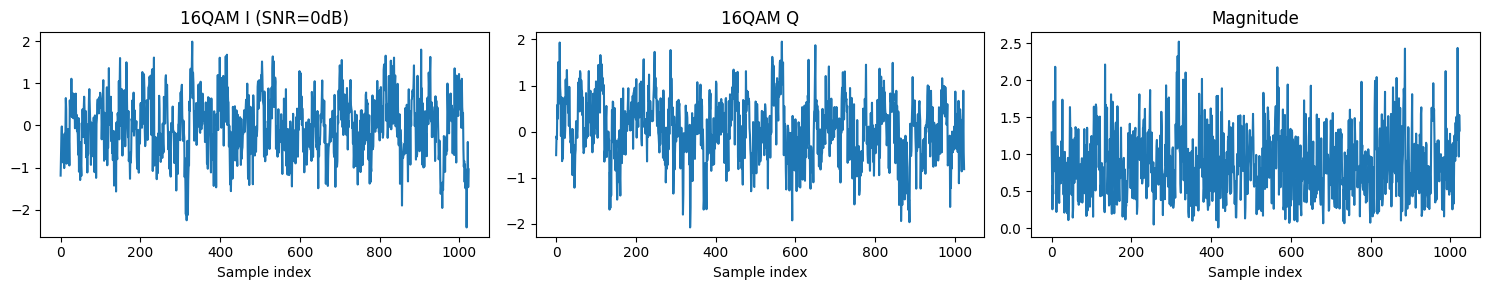

In [10]:
plot_signals_by_modulation_snr(
    mod_name='4ASK',
    snr_level=24,
    num_samples=2,
    file_path=my_wsl_file_path_dataset,
    classes_fixed=fixed_classes,
    Y_arr=Y_arr,
    Z_arr=Z_arr
)

# Plot 3 random 16QAM signals at 0 dB
plot_signals_by_modulation_snr(
    mod_name='16QAM',
    snr_level=0,
    num_samples=3,
    file_path=my_wsl_file_path_dataset,
    classes_fixed=fixed_classes,
    Y_arr=Y_arr,
    Z_arr=Z_arr
)

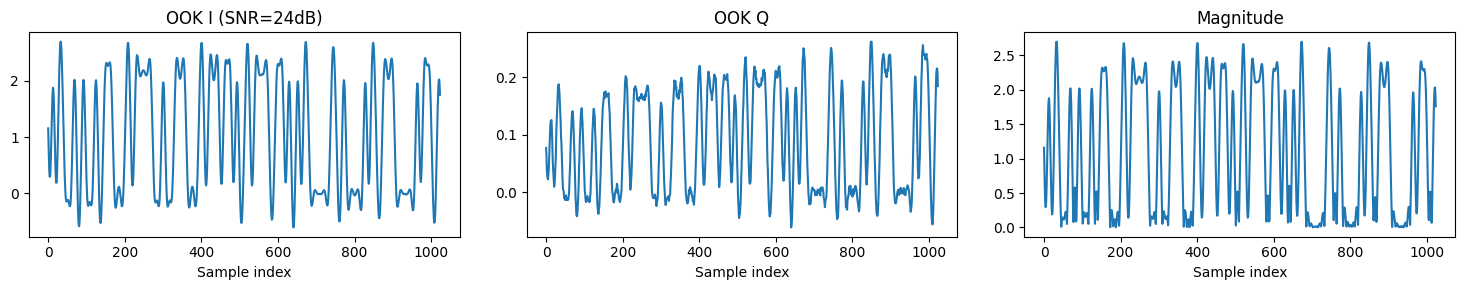

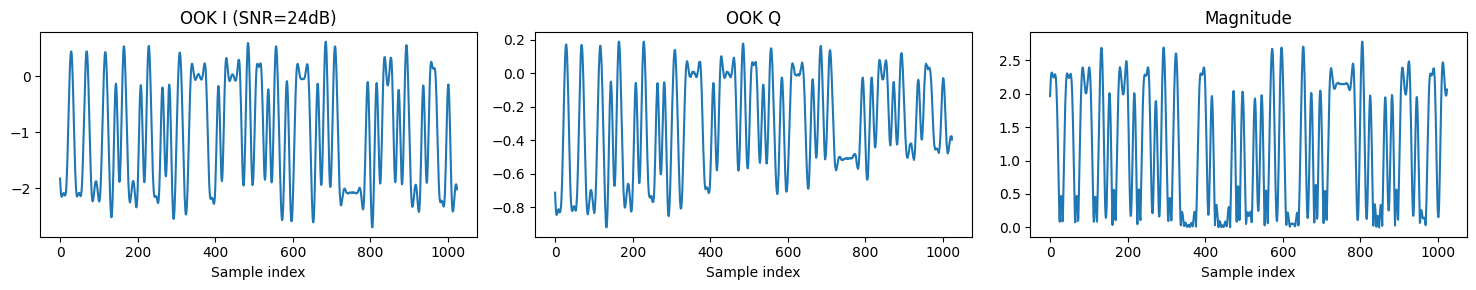

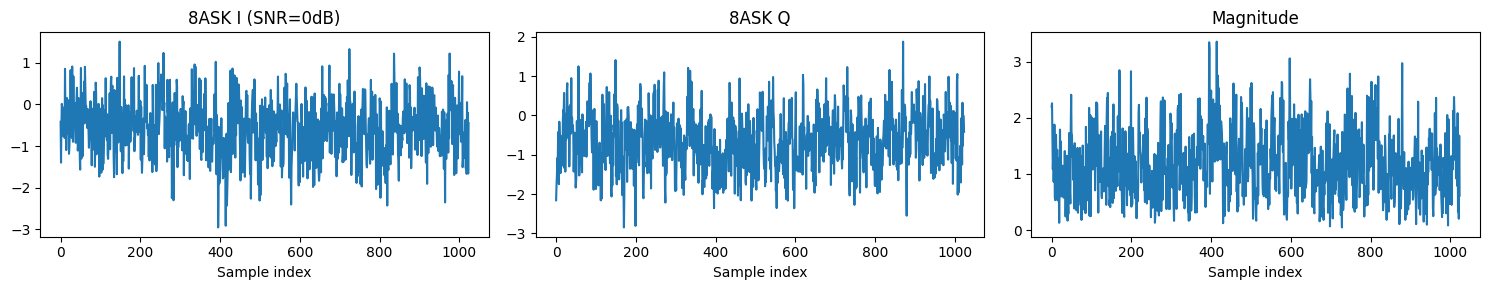

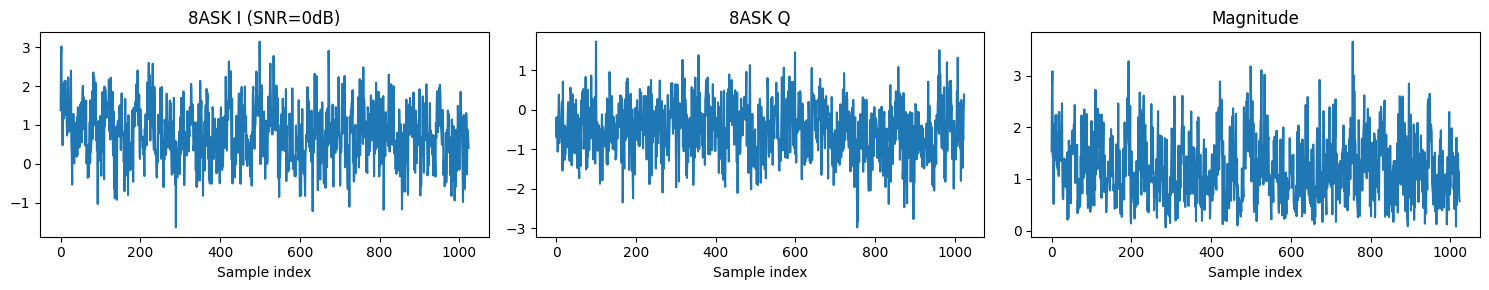

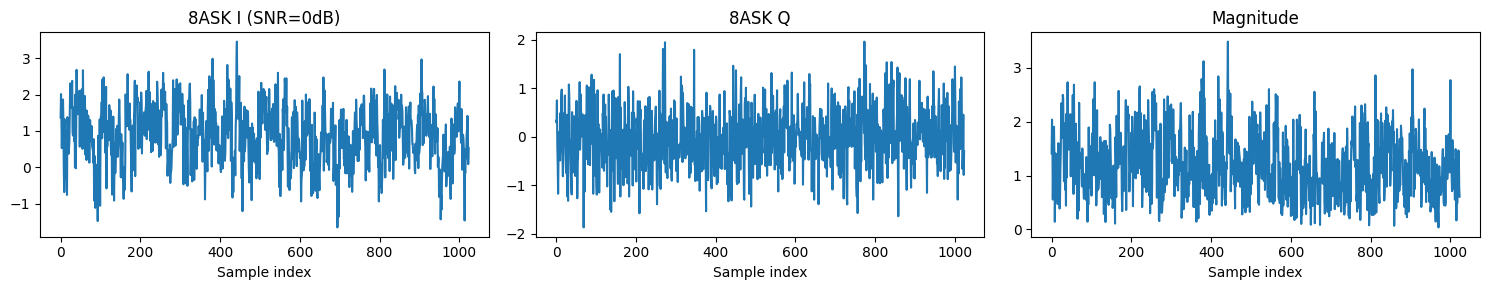

In [11]:
plot_signals_by_modulation_snr(
    mod_name='OOK',
    snr_level=24,
    num_samples=2,
    file_path=my_wsl_file_path_dataset,
    classes_fixed=fixed_classes,
    Y_arr=Y_arr,
    Z_arr=Z_arr
)

# Plot 3 random 16QAM signals at 0 dB
plot_signals_by_modulation_snr(
    mod_name='8ASK',
    snr_level=0,
    num_samples=3,
    file_path=my_wsl_file_path_dataset,
    classes_fixed=fixed_classes,
    Y_arr=Y_arr,
    Z_arr=Z_arr
)

### BPSK MODULATION 

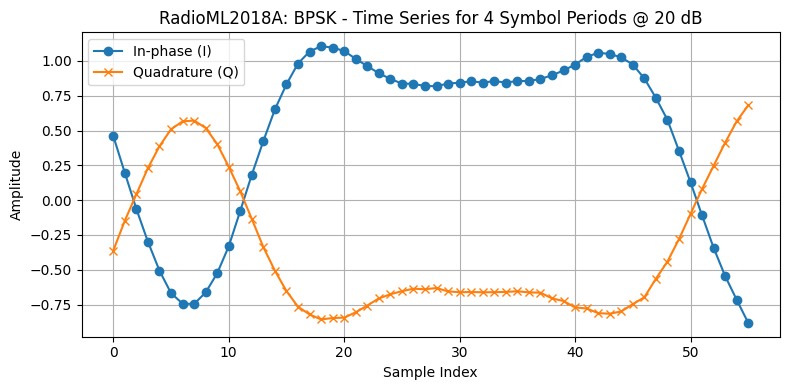

In [12]:
# --- Parameters ---
file_path = my_wsl_file_path_dataset   # Your HDF5 dataset path
modulation = 'BPSK'    # Any you like: 'BPSK', 'QPSK', '16QAM', etc.
snr_level = 20
samples_per_symbol = 14  # Typical, but check your dataset!
symbol_periods_to_plot = 4  # Number of symbol periods you want to visualize

# --- Helper to find sample index ---
idxs = find_modulation_snr_indices(modulation, snr_level, fixed_classes, Y_arr, Z_arr)
if len(idxs) == 0:
    raise ValueError("No sample found for this modulation/SNR combination.")
sample_idx = idxs[0]

# --- Load I/Q data for selected sample ---
with h5py.File(file_path, 'r',locking=False) as f:
    X_ds = f['X']
    sample = X_ds[sample_idx, :, :]  # shape: [N_samples, 2]
    I = sample[:, 0]
    Q = sample[:, 1]

# --- Choose a symbol boundary (for realistic symbol plotting, align to symbol start) ---
# Here, just pick the first symbol(s)
N = samples_per_symbol * symbol_periods_to_plot
I_period = I[:N]
Q_period = Q[:N]

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.plot(I_period, label='In-phase (I)', marker='o')
plt.plot(Q_period, label='Quadrature (Q)', marker='x')
plt.title(f"RadioML2018A: {modulation} - Time Series for {symbol_periods_to_plot} Symbol Periods @ {snr_level} dB")
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21976\4284786026.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_energy = np.trapz(energy_density)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21976\4284786026.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  transition_energy = np.trapz(energy_density[transition_mask])


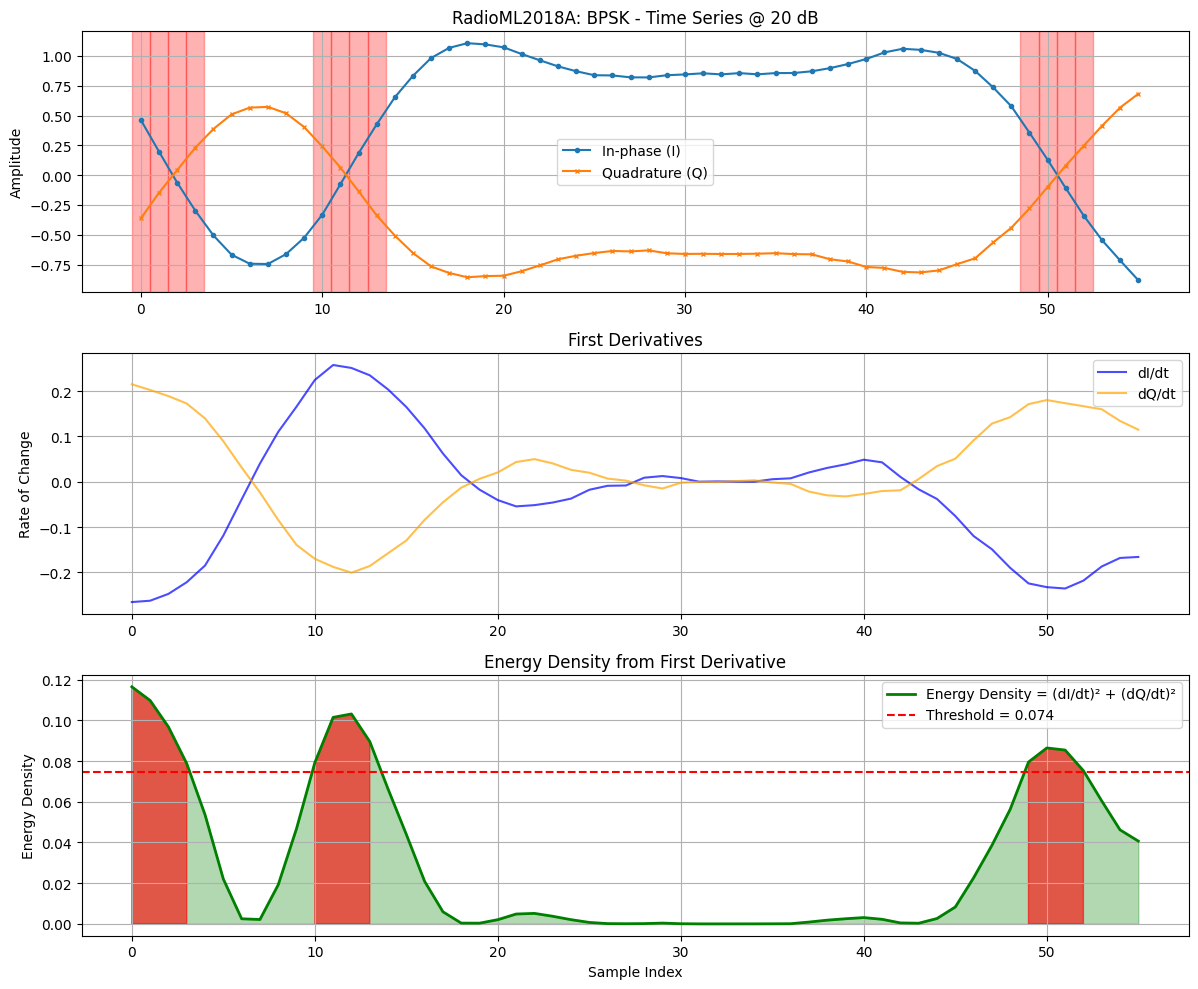

Total Energy: 1.614183
Transition Energy (from mask): 1.006065
Transition Energy Ratio (from mask): 62.33%

Manual Region Analysis (for 3 identified transitions):
Transition 1 Energy (samples 0-8): 0.433459
Transition 2 Energy (samples 10-16): 0.454534
Transition 3 Energy (samples 48-55): 0.481800

Energy per Symbol Period (using sps=14, analyzing 4 periods):
Symbol 1 Energy (samples 0-13): 0.818605
Symbol 2 Energy (samples 14-27): 0.123355
Symbol 3 Energy (samples 28-41): 0.010096
Symbol 4 Energy (samples 42-55): 0.582708
Average Energy per Symbol: 0.383691


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21976\4284786026.py:118: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(region_energy_density)


In [13]:
# --- Parameters ---
file_path = my_wsl_file_path_dataset  # Your HDF5 dataset path
modulation = 'BPSK'  # Any you like: 'BPSK', 'QPSK', '16QAM', etc.
snr_level = 20
samples_per_symbol = 14  # Typical, but check your dataset!
symbol_periods_to_plot = 4  # Number of symbol periods you want to visualize

# --- Helper to find sample index ---
idxs = find_modulation_snr_indices(modulation, snr_level, fixed_classes, Y_arr, Z_arr)
if len(idxs) == 0:
    raise ValueError("No sample found for this modulation/SNR combination.")
sample_idx = idxs[0]

# --- Load I/Q data for selected sample ---
with h5py.File(file_path, 'r',locking = False) as f:

    X_ds = f['X']
    sample = X_ds[sample_idx, :, :]  # shape: [N_samples, 2]

I = sample[:, 0]
Q = sample[:, 1]

# --- Choose a symbol boundary ---
N = samples_per_symbol * symbol_periods_to_plot
I_period = I[:N]
Q_period = Q[:N]

# --- Calculate First Derivatives ---
# Using numpy gradient for numerical differentiation
dI_dt = np.gradient(I_period)
dQ_dt = np.gradient(Q_period)

# --- Calculate Energy using First Derivative ---
# Energy = integral of (dI/dt)^2 + (dQ/dt)^2
energy_density = dI_dt**2 + dQ_dt**2

# Total energy over the entire period
total_energy = np.trapz(energy_density)

# --- Identify Transition Regions (Shifting areas) ---
# You can define thresholds based on derivative magnitude
threshold = np.std(energy_density) * 2  # Adjust this multiplier as needed
transition_mask = energy_density > threshold

# Calculate energy only in transition regions
transition_energy = np.trapz(energy_density[transition_mask])

# --- Plotting ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: Original I/Q signals
ax1.plot(I_period, label='In-phase (I)', marker='o', markersize=3)
ax1.plot(Q_period, label='Quadrature (Q)', marker='x', markersize=3)
ax1.set_title(f"RadioML2018A: {modulation} - Time Series @ {snr_level} dB")
ax1.set_ylabel('Amplitude')
ax1.grid(True)
ax1.legend()

# Highlight transition regions
for i in range(len(transition_mask)):
    if transition_mask[i]:
        ax1.axvspan(i-0.5, i+0.5, alpha=0.3, color='red')

# Plot 2: First derivatives
ax2.plot(dI_dt, label='dI/dt', color='blue', alpha=0.7)
ax2.plot(dQ_dt, label='dQ/dt', color='orange', alpha=0.7)
ax2.set_title('First Derivatives')
ax2.set_ylabel('Rate of Change')
ax2.grid(True)
ax2.legend()

# Plot 3: Energy density
ax3.plot(energy_density, label='Energy Density = (dI/dt)² + (dQ/dt)²', color='green', linewidth=2)
ax3.fill_between(range(len(energy_density)), energy_density, alpha=0.3, color='green')
ax3.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.3f}')
ax3.set_title('Energy Density from First Derivative')
ax3.set_xlabel('Sample Index')
ax3.set_ylabel('Energy Density')
ax3.grid(True)
ax3.legend()

# Highlight high-energy transition regions
ax3.fill_between(range(len(energy_density)), energy_density,
                where=transition_mask, alpha=0.6, color='red',
                label='Transition Regions')

plt.tight_layout()
plt.show()

# --- Print Results (Existing part from your snippet) ---
# Ensure these variables are defined and calculated based on the data from image_f5cf78.png
if 'total_energy' in locals() or 'total_energy' in globals():
    print(f"Total Energy: {total_energy:.6f}")
    if 'transition_energy' in locals() or 'transition_energy' in globals():
        print(f"Transition Energy (from mask): {transition_energy:.6f}")
        if total_energy != 0:
            print(f"Transition Energy Ratio (from mask): {transition_energy/total_energy:.2%}")
        else:
            print("Transition Energy Ratio (from mask): Total energy is zero, ratio undefined.")
    else:
        print("Warning: 'transition_energy' (from mask) not defined.")
else:
    print("Warning: 'total_energy' not defined.")


# --- Function to calculate energy in a specific region ---
def calculate_region_energy(start_idx, end_idx, energy_density_array):
    """Calculate energy in a specific region from the given energy_density_array"""
    # Ensure indices are within bounds
    start_idx = max(0, start_idx)
    end_idx = min(len(energy_density_array) - 1, end_idx)

    if start_idx > end_idx:
        print(f"Warning: Invalid range for energy calculation (start_idx={start_idx}, end_idx={end_idx}). Returning 0.")
        return 0.0

    region_energy_density = energy_density_array[start_idx:end_idx+1]
    return np.trapz(region_energy_density)

# --- MODIFIED: Manual Integration for Specific Regions identified from image_f5cf78.png ---
print(f"\nManual Region Analysis (for 3 identified transitions):")

# Define the start and end indices for the 3 transitions
# (based on image_f5cf78.png, x-axis up to ~56, Threshold = 0.074)
identified_transitions_from_image_f5cf78 = [
    {"label": "Transition 1", "start": 0, "end": 8},
    {"label": "Transition 2", "start": 10, "end": 16},
    {"label": "Transition 3", "start": 48, "end": 55},
]

# Ensure energy_density is defined and populated before this loop
if 'energy_density' in locals() or 'energy_density' in globals():
    if len(energy_density) > 0: # Check if energy_density is not empty
        for transition in identified_transitions_from_image_f5cf78:
            current_transition_energy = calculate_region_energy(
                transition["start"],
                transition["end"],
                energy_density
            )
            print(f"{transition['label']} Energy (samples {transition['start']}-{transition['end']}): {current_transition_energy:.6f}")
    else:
        print("Warning: 'energy_density' array is empty. Cannot perform manual region analysis.")
else:
    print("Warning: 'energy_density' variable is not defined. Cannot perform manual region analysis.")

# --- Energy per Symbol Period (Existing part from your snippet, with robustness) ---
# This section assumes 'samples_per_symbol' and 'symbol_periods_to_plot'
# are appropriately set for the 'energy_density' array from image_f5cf78.png.
# For image_f5cf78.png, N is ~56. If sps=14, then symbol_periods_to_plot would be 4.

if ('energy_density' in locals() or 'energy_density' in globals()) and \
   ('samples_per_symbol' in locals() or 'samples_per_symbol' in globals()):
    if len(energy_density) > 0 and samples_per_symbol > 0:
        actual_symbol_periods = len(energy_density) // samples_per_symbol

        # Use 'symbol_periods_to_plot' if defined and valid, otherwise use actual_symbol_periods
        num_periods_to_analyze = symbol_periods_to_plot \
            if ('symbol_periods_to_plot' in locals() or 'symbol_periods_to_plot' in globals()) \
               and symbol_periods_to_plot <= actual_symbol_periods \
            else actual_symbol_periods

        print(f"\nEnergy per Symbol Period (using sps={samples_per_symbol}, analyzing {num_periods_to_analyze} periods):")
        energy_per_symbol_list = [] # Renamed to avoid conflict if 'energy_per_symbol' var is used elsewhere

        for symbol_idx in range(num_periods_to_analyze):
            start_idx = symbol_idx * samples_per_symbol
            end_idx = (symbol_idx + 1) * samples_per_symbol - 1

            symbol_energy = calculate_region_energy(start_idx, end_idx, energy_density)
            energy_per_symbol_list.append(symbol_energy)
            print(f"Symbol {symbol_idx+1} Energy (samples {start_idx}-{end_idx}): {symbol_energy:.6f}")

        if energy_per_symbol_list:
            print(f"Average Energy per Symbol: {np.mean(energy_per_symbol_list):.6f}")
        else:
            print("No symbol periods to analyze for energy per symbol.")
    else:
        print("Warning: 'energy_density' is empty or 'samples_per_symbol' is zero. Cannot calculate energy per symbol period.")
else:
    print("Warning: 'energy_density' or 'samples_per_symbol' not defined. Cannot calculate energy per symbol period.")

In [14]:
# assuming I_period, Q_period, samples_per_symbol, symbol_periods_to_plot defined

e = I_period**2 + Q_period**2
M = samples_per_symbol
P = symbol_periods_to_plot

# symbol‐by‐symbol energies
sym_E = np.array([ e[k*M:(k+1)*M].sum() for k in range(P) ])
total_E = sym_E.sum()

# transition regions (you can pick k=0 boundary and k=P-1 boundary)
t1 = e[8:13].sum()
t2 = e[48:53].sum()
trans_E = t1 + t2
trans_ratio = 100 * trans_E / total_E

print(f"Total Energy:           {total_E:.6f}")
print(f"Transition Energy:      {trans_E:.6f}")
print(f"Transition Energy Ratio:{trans_ratio:.2f}%\n")

for i, Ei in enumerate(sym_E, start=1):
    print(f"Symbol {i} Energy:      {Ei:.6f}")
print(f"Average Energy/symbol:  {sym_E.mean():.6f}")

Total Energy:           54.816658
Transition Energy:      2.332405
Transition Energy Ratio:4.25%

Symbol 1 Energy:      5.091459
Symbol 2 Energy:      19.944223
Symbol 3 Energy:      17.421299
Symbol 4 Energy:      12.359678
Average Energy/symbol:  13.704165


Detected symbol‐boundary sample indices: [501 989]


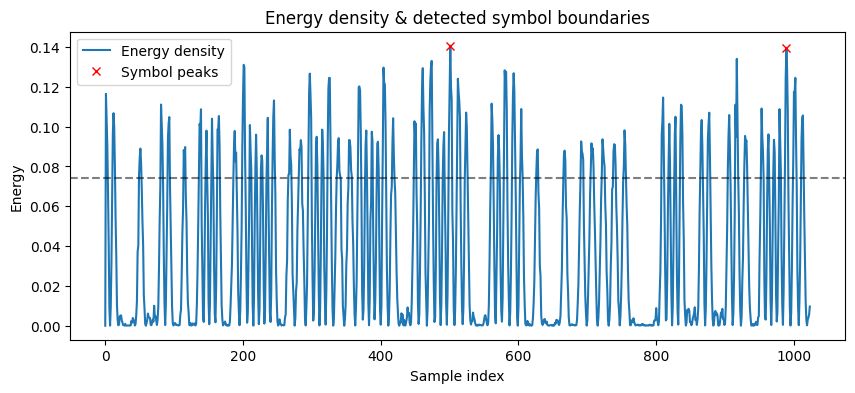

In [15]:
# helper (re-use your energy density code up through region detection)
def compute_energy_density(I, Q):
    dI = np.diff(I, prepend=I[0])
    dQ = np.diff(Q, prepend=Q[0])
    return dI**2 + dQ**2

def detect_symbol_boundaries(energy, n_peaks=2, distance=None, height=None):
    # find local maxima in the energy-density curve
    peaks, props = sig.find_peaks(energy, distance=distance, height=height)
    # sort by peak height descending and return top n_peaks indices
    top = peaks[np.argsort(props['peak_heights'])[::-1][:n_peaks]]
    return np.sort(top)

# --- load a single sample's I/Q at 20dB from your HDF5 ---
file_path = my_wsl_file_path_dataset
modulation  = 'BPSK'
snr_level   = 20

idxs = find_modulation_snr_indices(modulation, snr_level, fixed_classes, Y_arr, Z_arr)
sample_idx = idxs[0]

with h5py.File(file_path,'r',locking = False) as f:
    X = f['X'][sample_idx]  # shape (1024,2)
    I, Q = X[:,0], X[:,1]

# --- compute energy density ---
energy = compute_energy_density(I, Q)

# --- find the two main transition peaks ---
# require peaks at least samples_per_symbol apart
distance = samples_per_symbol - 2  
boundaries = detect_symbol_boundaries(energy, n_peaks=2,
                                      distance=distance,
                                      height=np.percentile(energy,75))

print("Detected symbol‐boundary sample indices:", boundaries)

# --- plot to verify ---
plt.figure(figsize=(10,4))
plt.plot(energy, label='Energy density')
plt.plot(boundaries, energy[boundaries], 'rx', label='Symbol peaks')
plt.axhline(np.percentile(energy,75), color='k', linestyle='--', alpha=0.5)
plt.legend(); plt.title("Energy density & detected symbol boundaries")
plt.xlabel("Sample index"); plt.ylabel("Energy")
plt.show()


Symbol center sample indices: [508 522 536 550 564 578 592 606 620 634 648 662 676 690 704 718 732 746
 760 774 788 802 816 830 844 858 872 886 900 914 928 942 956 970]


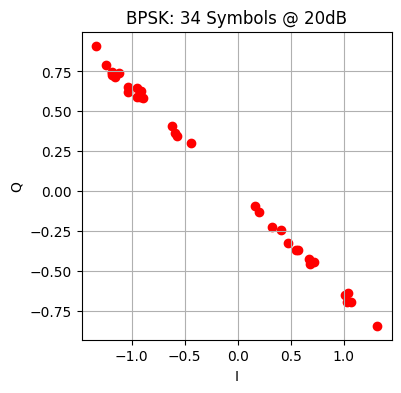

In [16]:
# --- assume we already have these from the previous step ---
# I, Q        : full time‐series length Nsamples (e.g. 1024)
# boundaries  : sorted array of two transition indices, e.g. [ 10, 50 ]
# samples_per_symbol = 14

# total symbols across these two transitions = (bound2 - bound1) / samples_per_symbol
num_symbols = int((boundaries[1] - boundaries[0]) / samples_per_symbol)

# compute the center offset
half_sp = samples_per_symbol // 2

# generate all symbol mid‐points between the two peaks
symbol_centers = boundaries[0] + half_sp + np.arange(0, num_symbols) * samples_per_symbol
symbol_centers = symbol_centers.astype(int)

print("Symbol center sample indices:", symbol_centers)

# pull out one I/Q per symbol
I_sym = I[symbol_centers]
Q_sym = Q[symbol_centers]

# (Optionally) plot these points on your constellation:
plt.figure(figsize=(4,4))
plt.scatter(I_sym, Q_sym, c='r', marker='o')
plt.title(f"{modulation}: {num_symbols} Symbols @ {snr_level}dB")
plt.xlabel("I"); plt.ylabel("Q"); plt.grid(True)
plt.show()


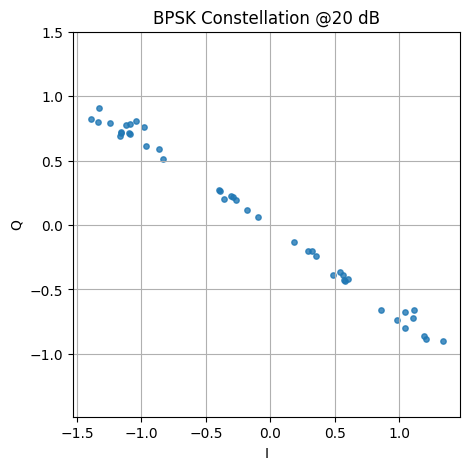

In [17]:
N = len(I)                     # e.g. 1024
sps = 24                   # samples per symbol in RadioML2018.01A
symbol_centers = np.arange(sps//2, N, sps, dtype=int)

# now pick those samples
I_pts = I[symbol_centers]
Q_pts = Q[symbol_centers]

# constellation scatter
plt.figure(figsize=(5,5))
plt.scatter(I_pts, Q_pts, s=15, alpha=0.8)
plt.title(f"BPSK Constellation @{snr_level} dB")
plt.xlabel("I"); plt.ylabel("Q")
plt.grid(True)
plt.axis("equal")
plt.show()

c:\Users\ASUS\.conda\envs\dl-env\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ASUS\.conda\envs\dl-env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\.conda\envs\dl-env\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\.conda\envs\dl-env\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ASUS\.conda\envs\dl-env\Lib\subprocess.py", line 1538, in _execute_child


Estimasi Titik Pusat BPSK:
Pusat 1: I=0.7582, Q=-0.5315
Pusat 2: I=-0.8402, Q=0.5524


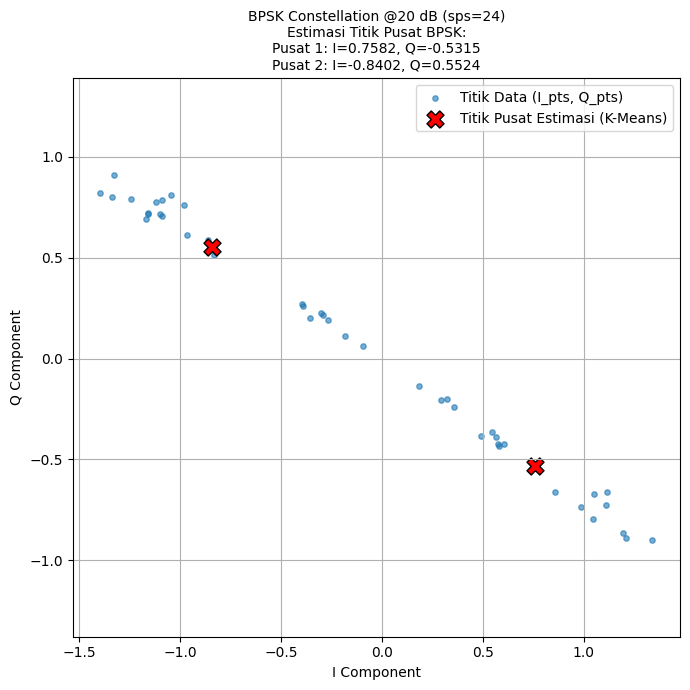

In [18]:
from sklearn.cluster import KMeans
N = len(I)
sps = 24 # Pengaturan sps Anda saat ini

# Logika untuk menentukan symbol_centers berdasarkan sps
if sps == 1:
    # Jika sps adalah 1, kita anggap setiap sampel adalah sebuah simbol.
    # Ini berarti I_pts akan menjadi I, dan Q_pts akan menjadi Q.
    symbol_centers = np.arange(N, dtype=int)
else:
    # Logika downsampling jika sps > 1 (mengambil sampel di tengah durasi simbol)
    # Pastikan N cukup besar untuk logika ini
    if N > sps//2 : # Perlu setidaknya satu titik pusat potensial
        symbol_centers = np.arange(sps//2, N, sps, dtype=int)
    else:
        symbol_centers = np.array([], dtype=int) # Kosong jika N terlalu kecil

# Pastikan symbol_centers tidak kosong sebelum mengambil sampel
if len(symbol_centers) > 0:
    I_pts = I[symbol_centers]
    Q_pts = Q[symbol_centers]
else:
    print(f"Peringatan: Tidak ada 'symbol_centers' yang ditemukan dengan N={N} dan sps={sps}.")
    print("Memplot semua titik I, Q jika memungkinkan, atau tidak ada titik jika I, Q kosong.")
    I_pts = I # Fallback ke semua titik jika symbol_centers kosong tapi I/Q ada
    Q_pts = Q

# --- Modifikasi untuk menemukan titik pusat menggunakan K-Means ---
center_points = None # Inisialisasi
estimated_centers_text = "Tidak ada titik pusat yang diestimasi."

# K-Means memerlukan setidaknya sejumlah sampel yang sama dengan jumlah klaster
if len(I_pts) >= 2: # Untuk n_clusters=2, kita butuh setidaknya 2 titik
    # Gabungkan I_pts dan Q_pts menjadi satu array untuk K-Means
    # Bentuknya harus (n_samples, n_features), di mana n_features=2 (I dan Q)
    points_for_clustering = np.vstack((I_pts, Q_pts)).T

    # Inisialisasi K-Means dengan 2 klaster (karena BPSK memiliki 2 titik konstelasi)
    # random_state untuk reproduktifitas, n_init='auto' untuk menekan warning
    kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')

    # Lakukan clustering pada titik-titik (I_pts, Q_pts)
    kmeans.fit(points_for_clustering)

    # Dapatkan koordinat titik pusat klaster yang ditemukan
    center_points = kmeans.cluster_centers_
    # center_points akan menjadi array [[I_center1, Q_center1], [I_center2, Q_center2]]

    estimated_centers_text = (
        f"Estimasi Titik Pusat BPSK:\n"
        f"Pusat 1: I={center_points[0,0]:.4f}, Q={center_points[0,1]:.4f}\n"
        f"Pusat 2: I={center_points[1,0]:.4f}, Q={center_points[1,1]:.4f}"
    )
    print(estimated_centers_text)
else:
    print("Tidak cukup titik data (I_pts) untuk melakukan clustering K-Means (dibutuhkan minimal 2).")
# --- Akhir Modifikasi ---

# Visualisasi konstelasi
plt.figure(figsize=(7,7)) # Ukuran disesuaikan agar legenda dan judul muat
plt.scatter(I_pts, Q_pts, s=15, alpha=0.6, label='Titik Data (I_pts, Q_pts)')

# Plot titik pusat estimasi jika ditemukan
if center_points is not None:
    plt.scatter(center_points[:,0], center_points[:,1], s=150, c='red', marker='X', edgecolor='black', label='Titik Pusat Estimasi (K-Means)')

plt.title(f"BPSK Constellation @{snr_level} dB (sps={sps})\n{estimated_centers_text}", fontsize=10)
plt.xlabel("I Component")
plt.ylabel("Q Component")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.tight_layout() # Menyesuaikan layout agar semua elemen terlihat baik
plt.show()


Analyzing Frame Index: 401408 (BPSK @ 20dB)

--- Calculating BPSK Constellation using Energy per Symbol (sps=8) ---
Number of constellation points: 128
I-component statistics:
  Mean: -0.1556
  Std:  0.7146
  Range: [-1.2463, 1.2028]
Q-component statistics:
  Mean: 0.1003
  Std:  0.4879
  Range: [-0.8215, 0.8365]

RMS Energy Analysis:
I RMS Energy - Mean: 0.7728, Std: 0.2661
Q RMS Energy - Mean: 0.5264, Std: 0.1820

--- BPSK Constellation Plots (sps=8) ---


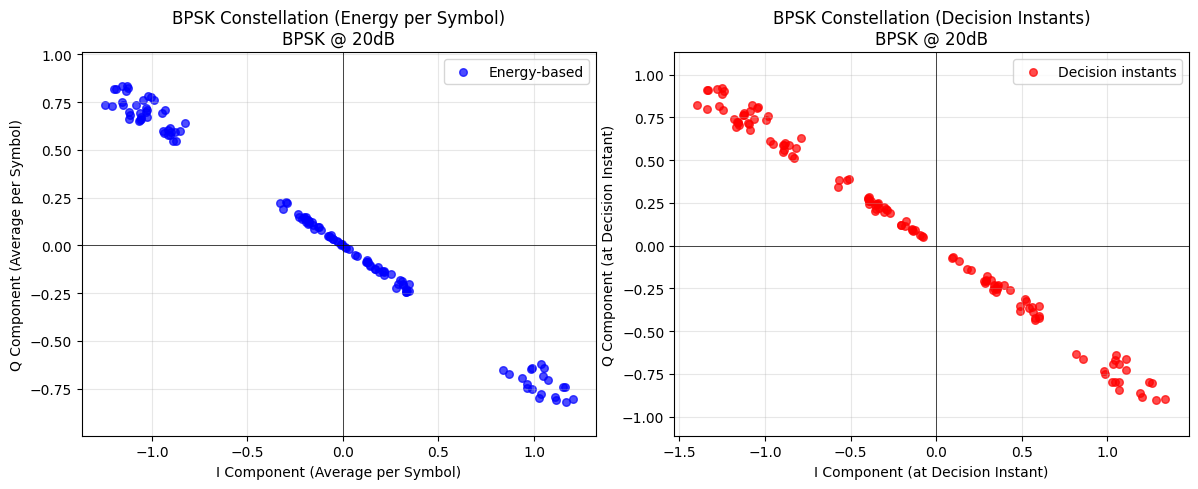

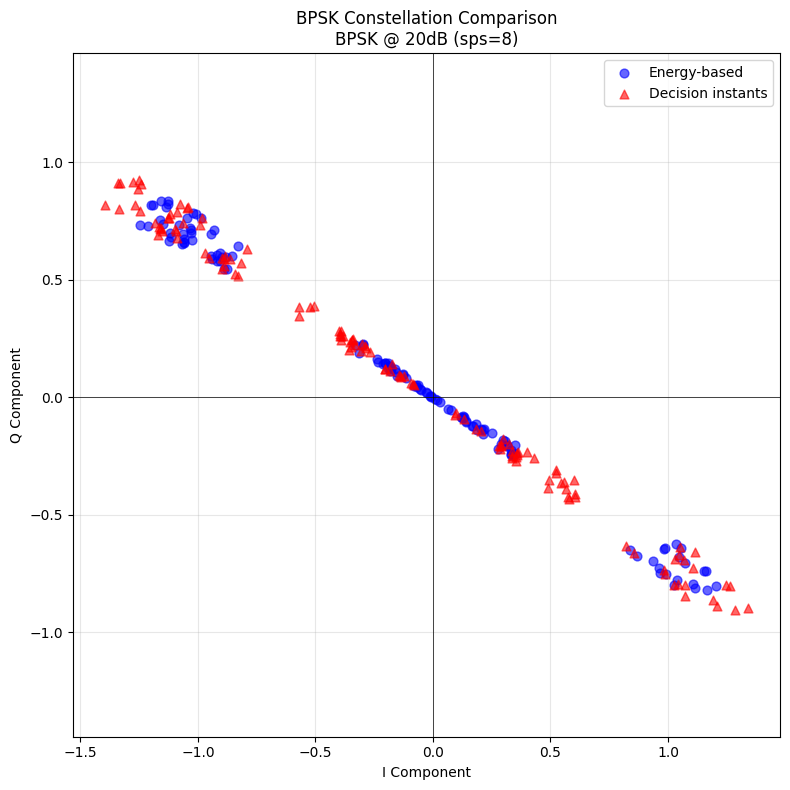

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import h5py # For loading data
from sklearn.cluster import KMeans # For constellation K-Means (optional)

# --- Parameters for selecting THE ONE FRAME ---
# Ensure FILE_PATH is correctly defined in your environment
# Example: FILE_PATH = 'path/to/your/RadioML2018.01A.h5'
if 'my_wsl_file_path_dataset' not in locals():
    raise ValueError("FILE_PATH is not defined. Please set the path to your HDF5 dataset.")

modulation_to_select = 'BPSK'
snr_to_select = 20 # You can change this SNR level

# --- Key Parameter: True Samples Per Symbol for BPSK in RadioML2018.A ---
true_sps = 8

# --- Helper function placeholder (ensure this is correctly defined) ---
def find_modulation_snr_indices(mod, snr, classes_list, y_labels_array, z_snr_array):
    """
    Finds indices for a given modulation string and SNR.
    Placeholder - adapt to your actual label format and loading.
    """
    print("Warning: Using placeholder 'find_modulation_snr_indices'. Adapt to your data.")
    mod_target_str = mod
    mod_match_flags = np.zeros(len(y_labels_array), dtype=bool)
    for i, label_from_y in enumerate(y_labels_array):
        current_label_str = label_from_y.decode('utf-8') if isinstance(label_from_y, bytes) else str(label_from_y)
        if current_label_str == mod_target_str:
            mod_match_flags[i] = True
    mod_indices = np.where(mod_match_flags)[0]
    snr_match_indices = np.where(z_snr_array == snr)[0]
    common_indices = np.intersect1d(mod_indices, snr_match_indices)
    return common_indices.tolist()

# --- Load Labels and SNRs (Crucial and dataset-specific) ---
try:
    with h5py.File(my_wsl_file_path_dataset, 'r',locking=False) as f:
        if 'Y' in f and 'Z' in f:
            Y_arr_raw = f['Y'][:]
            Z_arr = f['Z'][:, 0]
            if 'fixed_classes' not in globals() or fixed_classes is None:
                fixed_classes = ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-DSB-WC', 'AM-DSB-SC', 'AM-SSB-WC', 'AM-SSB-SC', 'FM', 'GMSK', 'OQPSK']
            if Y_arr_raw.ndim == 2: # One-hot encoded
                Y_arr_int_labels = np.argmax(Y_arr_raw, axis=1)
                Y_arr = np.array([fixed_classes[i] for i in Y_arr_int_labels])
            else:
                 Y_arr = np.array([label.decode('utf-8') if isinstance(label, bytes) else str(label) for label in Y_arr_raw])
            if 'fixed_classes' not in globals() or fixed_classes is None:
                fixed_classes = np.unique(Y_arr).tolist()
        else:
            raise KeyError("Y or Z dataset not found in HDF5 file.")
except Exception as e:
    print(f"Error loading or processing Y/Z from HDF5: {e}.")
    if 'Y_arr' not in locals(): Y_arr = np.array(['BPSK'])
    if 'Z_arr' not in locals(): Z_arr = np.array([20])
    if 'fixed_classes' not in locals(): fixed_classes = ['BPSK']

# --- Find the specific index ---
idxs = find_modulation_snr_indices(modulation_to_select, snr_to_select, fixed_classes, Y_arr, Z_arr)
if len(idxs) == 0:
    raise ValueError(f"No sample found for {modulation_to_select} / {snr_to_select}dB combination.")
sample_idx_to_load = idxs[0]
print(f"Analyzing Frame Index: {sample_idx_to_load} ({modulation_to_select} @ {snr_to_select}dB)")

# --- Load I/Q data for THE ONE selected frame ---
with h5py.File(my_wsl_file_path_dataset, 'r',locking = False) as f:
    X_ds = f['X']
    one_frame_iq = X_ds[sample_idx_to_load, :, :]

I_full_frame = one_frame_iq[:, 0]
Q_full_frame = one_frame_iq[:, 1]

# --- Function to calculate energy per symbol for constellation analysis ---
def calculate_symbol_energy_constellation(I_frame_data, Q_frame_data, sps_val):
    """
    Calculates the energy per symbol and returns constellation points.
    For BPSK, this gives us the classical constellation representation.
    
    Args:
        I_frame_data (np.array): I component samples for the entire frame.
        Q_frame_data (np.array): Q component samples for the entire frame.
        sps_val (int): Samples per symbol.
    Returns:
        tuple: (I_constellation, Q_constellation) - constellation points
    """
    # Ensure we have complete symbols
    min_length = min(len(I_frame_data), len(Q_frame_data))
    if min_length % sps_val != 0:
        num_total_samples_frame = (min_length // sps_val) * sps_val
        I_frame_data = I_frame_data[:num_total_samples_frame]
        Q_frame_data = Q_frame_data[:num_total_samples_frame]
        print(f"Warning: Frame length truncated to {num_total_samples_frame} for even symbol division.")

    num_symbols_frame = len(I_frame_data) // sps_val
    
    # Reshape both I and Q data into (num_symbols, sps_val) matrices
    I_reshaped = I_frame_data.reshape(num_symbols_frame, sps_val)
    Q_reshaped = Q_frame_data.reshape(num_symbols_frame, sps_val)
    
    # Calculate energy per symbol: sqrt(sum(I^2 + Q^2)) per symbol period
    # This gives us the magnitude, but for constellation we want the symbol values
    
    # Method 1: Average energy per symbol (classical approach)
    I_constellation = np.mean(I_reshaped, axis=1)  # Average I per symbol
    Q_constellation = np.mean(Q_reshaped, axis=1)  # Average Q per symbol
    
    return I_constellation, Q_constellation

def calculate_symbol_energy_per_component(component_frame_data, sps_val):
    """
    Calculates the RMS (Root Mean Square) energy per symbol for a single component.
    This is more appropriate for constellation analysis than squared sums.
    
    Args:
        component_frame_data (np.array): Single component (I or Q) samples.
        sps_val (int): Samples per symbol.
    Returns:
        np.array: RMS energy per symbol
    """
    if len(component_frame_data) % sps_val != 0:
        num_total_samples_frame = (len(component_frame_data) // sps_val) * sps_val
        component_frame_data = component_frame_data[:num_total_samples_frame]
        print(f"Warning: Frame length truncated to {num_total_samples_frame} for even symbol division.")

    num_symbols_frame = len(component_frame_data) // sps_val
    
    # Reshape the data into (num_symbols, sps_val) matrix
    reshaped_data = component_frame_data.reshape(num_symbols_frame, sps_val)
    
    # Calculate RMS energy per symbol: sqrt(mean(samples^2))
    rms_energy_per_symbol = np.sqrt(np.mean(reshaped_data**2, axis=1))
    
    return rms_energy_per_symbol

# --- Calculate constellation points using classical energy approach ---
print(f"\n--- Calculating BPSK Constellation using Energy per Symbol (sps={true_sps}) ---")

# Method 1: Calculate constellation points directly
I_constellation_energy, Q_constellation_energy = calculate_symbol_energy_constellation(I_full_frame, Q_full_frame, true_sps)

print(f"Number of constellation points: {len(I_constellation_energy)}")
print(f"I-component statistics:")
print(f"  Mean: {np.mean(I_constellation_energy):.4f}")
print(f"  Std:  {np.std(I_constellation_energy):.4f}")
print(f"  Range: [{np.min(I_constellation_energy):.4f}, {np.max(I_constellation_energy):.4f}]")

print(f"Q-component statistics:")
print(f"  Mean: {np.mean(Q_constellation_energy):.4f}")
print(f"  Std:  {np.std(Q_constellation_energy):.4f}")
print(f"  Range: [{np.min(Q_constellation_energy):.4f}, {np.max(Q_constellation_energy):.4f}]")

# Method 2: Calculate RMS energy per symbol for each component
I_rms_energy = calculate_symbol_energy_per_component(I_full_frame, true_sps)
Q_rms_energy = calculate_symbol_energy_per_component(Q_full_frame, true_sps)

print(f"\nRMS Energy Analysis:")
print(f"I RMS Energy - Mean: {np.mean(I_rms_energy):.4f}, Std: {np.std(I_rms_energy):.4f}")
print(f"Q RMS Energy - Mean: {np.mean(Q_rms_energy):.4f}, Std: {np.std(Q_rms_energy):.4f}")

# --- BPSK Constellation Plots ---
print(f"\n--- BPSK Constellation Plots (sps={true_sps}) ---")

# Plot 1: Energy-based constellation (averaged per symbol)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(I_constellation_energy, Q_constellation_energy, s=30, alpha=0.7, c='blue', label='Energy-based')
plt.title(f"BPSK Constellation (Energy per Symbol)\n{modulation_to_select} @ {snr_to_select}dB")
plt.xlabel("I Component (Average per Symbol)")
plt.ylabel("Q Component (Average per Symbol)")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()

# Plot 2: Traditional constellation (decision instants)
plt.subplot(1, 2, 2)
N_full_frame_samples = len(I_full_frame)
I_constellation_traditional = np.array([])
Q_constellation_traditional = np.array([])

if N_full_frame_samples >= true_sps // 2:
    decision_sample_indices = np.arange(true_sps // 2, N_full_frame_samples, true_sps, dtype=int)
    if len(decision_sample_indices) > 0:
        I_constellation_traditional = I_full_frame[decision_sample_indices]
        Q_constellation_traditional = Q_full_frame[decision_sample_indices]

if len(I_constellation_traditional) > 0:
    plt.scatter(I_constellation_traditional, Q_constellation_traditional, s=30, alpha=0.7, c='red', label='Decision instants')
    plt.title(f"BPSK Constellation (Decision Instants)\n{modulation_to_select} @ {snr_to_select}dB")
else:
    plt.text(0.5, 0.5, "No constellation points to plot.", ha='center', va='center')
    plt.title(f"BPSK Constellation (Decision Instants)\n{modulation_to_select} @ {snr_to_select}dB")

plt.xlabel("I Component (at Decision Instant)")
plt.ylabel("Q Component (at Decision Instant)")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()

plt.tight_layout()
plt.show()

# Plot 3: Combined comparison
plt.figure(figsize=(8, 8))
plt.scatter(I_constellation_energy, Q_constellation_energy, s=40, alpha=0.6, c='blue', label='Energy-based', marker='o')
if len(I_constellation_traditional) > 0:
    plt.scatter(I_constellation_traditional, Q_constellation_traditional, s=40, alpha=0.6, c='red', label='Decision instants', marker='^')

plt.title(f"BPSK Constellation Comparison\n{modulation_to_select} @ {snr_to_select}dB (sps={true_sps})")
plt.xlabel("I Component")
plt.ylabel("Q Component")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

Analyzing Frame Index: 417792 (BPSK @ 28dB)

--- Calculating BPSK Constellation using Energy per Symbol (sps=8) ---
Number of constellation points: 128
I-component statistics:
  Mean: 0.0164
  Std:  0.4367
  Range: [-0.6793, 0.6367]
Q-component statistics:
  Mean: -0.0479
  Std:  0.8091
  Range: [-1.1321, 1.1316]

RMS Energy Analysis:
I RMS Energy - Mean: 0.4731, Std: 0.0966
Q RMS Energy - Mean: 0.8839, Std: 0.1570

--- BPSK Constellation Plots (sps=8) ---


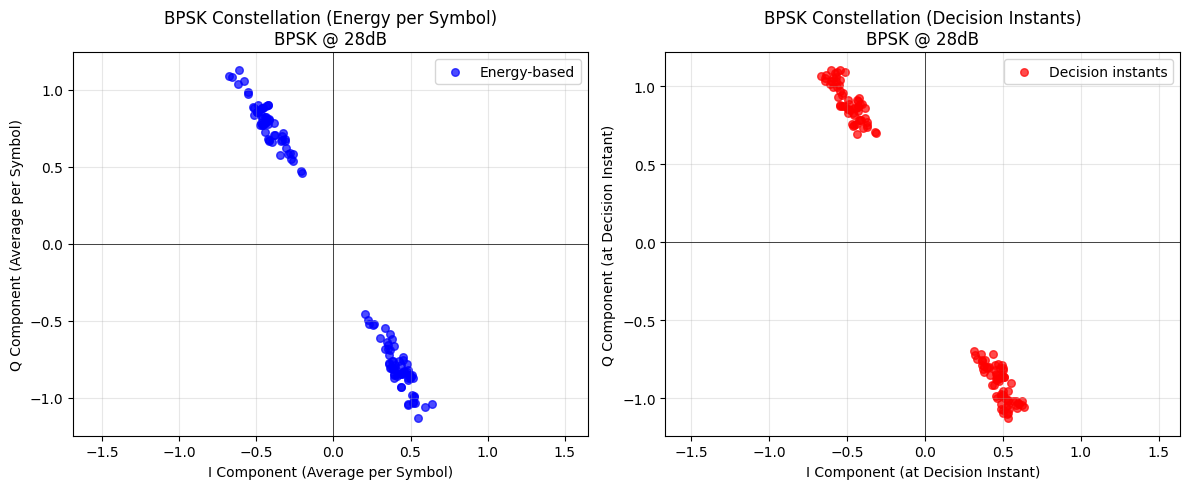

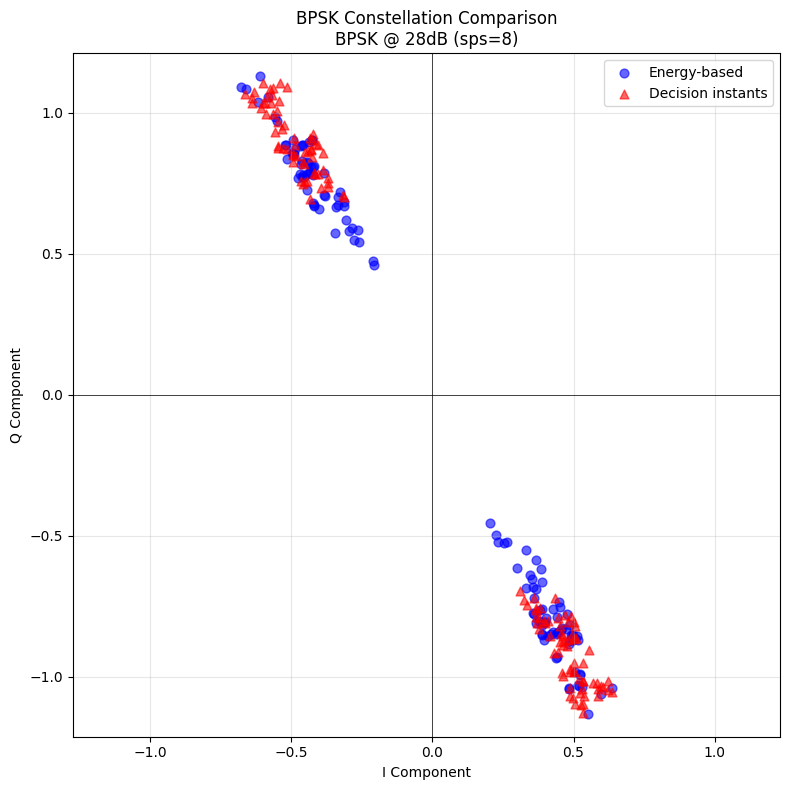

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import h5py # For loading data
from sklearn.cluster import KMeans # For constellation K-Means (optional)

# --- Parameters for selecting THE ONE FRAME ---
# Ensure FILE_PATH is correctly defined in your environment
# Example: FILE_PATH = 'path/to/your/RadioML2018.01A.h5'
if 'my_wsl_file_path_dataset' not in locals():
    raise ValueError("FILE_PATH is not defined. Please set the path to your HDF5 dataset.")

modulation_to_select = 'BPSK'
snr_to_select = 28 # You can change this SNR level

# --- Key Parameter: True Samples Per Symbol for BPSK in RadioML2018.A ---
true_sps = 8

# --- Helper function placeholder (ensure this is correctly defined) ---
def find_modulation_snr_indices(mod, snr, classes_list, y_labels_array, z_snr_array):
    """
    Finds indices for a given modulation string and SNR.
    Placeholder - adapt to your actual label format and loading.
    """
    print("Warning: Using placeholder 'find_modulation_snr_indices'. Adapt to your data.")
    mod_target_str = mod
    mod_match_flags = np.zeros(len(y_labels_array), dtype=bool)
    for i, label_from_y in enumerate(y_labels_array):
        current_label_str = label_from_y.decode('utf-8') if isinstance(label_from_y, bytes) else str(label_from_y)
        if current_label_str == mod_target_str:
            mod_match_flags[i] = True
    mod_indices = np.where(mod_match_flags)[0]
    snr_match_indices = np.where(z_snr_array == snr)[0]
    common_indices = np.intersect1d(mod_indices, snr_match_indices)
    return common_indices.tolist()

# --- Load Labels and SNRs (Crucial and dataset-specific) ---
try:
    with h5py.File(my_wsl_file_path_dataset, 'r',locking=False) as f:
        if 'Y' in f and 'Z' in f:
            Y_arr_raw = f['Y'][:]
            Z_arr = f['Z'][:, 0]
            if 'fixed_classes' not in globals() or fixed_classes is None:
                fixed_classes = ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-DSB-WC', 'AM-DSB-SC', 'AM-SSB-WC', 'AM-SSB-SC', 'FM', 'GMSK', 'OQPSK']
            if Y_arr_raw.ndim == 2: # One-hot encoded
                Y_arr_int_labels = np.argmax(Y_arr_raw, axis=1)
                Y_arr = np.array([fixed_classes[i] for i in Y_arr_int_labels])
            else:
                 Y_arr = np.array([label.decode('utf-8') if isinstance(label, bytes) else str(label) for label in Y_arr_raw])
            if 'fixed_classes' not in globals() or fixed_classes is None:
                fixed_classes = np.unique(Y_arr).tolist()
        else:
            raise KeyError("Y or Z dataset not found in HDF5 file.")
except Exception as e:
    print(f"Error loading or processing Y/Z from HDF5: {e}.")
    if 'Y_arr' not in locals(): Y_arr = np.array(['BPSK'])
    if 'Z_arr' not in locals(): Z_arr = np.array([20])
    if 'fixed_classes' not in locals(): fixed_classes = ['BPSK']

# --- Find the specific index ---
idxs = find_modulation_snr_indices(modulation_to_select, snr_to_select, fixed_classes, Y_arr, Z_arr)
if len(idxs) == 0:
    raise ValueError(f"No sample found for {modulation_to_select} / {snr_to_select}dB combination.")
sample_idx_to_load = idxs[0]
print(f"Analyzing Frame Index: {sample_idx_to_load} ({modulation_to_select} @ {snr_to_select}dB)")

# --- Load I/Q data for THE ONE selected frame ---
with h5py.File(my_wsl_file_path_dataset, 'r',locking = False) as f:
    X_ds = f['X']
    one_frame_iq = X_ds[sample_idx_to_load, :, :]

I_full_frame = one_frame_iq[:, 0]
Q_full_frame = one_frame_iq[:, 1]

# --- Function to calculate energy per symbol for constellation analysis ---
def calculate_symbol_energy_constellation(I_frame_data, Q_frame_data, sps_val):
    """
    Calculates the energy per symbol and returns constellation points.
    For BPSK, this gives us the classical constellation representation.
    
    Args:
        I_frame_data (np.array): I component samples for the entire frame.
        Q_frame_data (np.array): Q component samples for the entire frame.
        sps_val (int): Samples per symbol.
    Returns:
        tuple: (I_constellation, Q_constellation) - constellation points
    """
    # Ensure we have complete symbols
    min_length = min(len(I_frame_data), len(Q_frame_data))
    if min_length % sps_val != 0:
        num_total_samples_frame = (min_length // sps_val) * sps_val
        I_frame_data = I_frame_data[:num_total_samples_frame]
        Q_frame_data = Q_frame_data[:num_total_samples_frame]
        print(f"Warning: Frame length truncated to {num_total_samples_frame} for even symbol division.")

    num_symbols_frame = len(I_frame_data) // sps_val
    
    # Reshape both I and Q data into (num_symbols, sps_val) matrices
    I_reshaped = I_frame_data.reshape(num_symbols_frame, sps_val)
    Q_reshaped = Q_frame_data.reshape(num_symbols_frame, sps_val)
    
    # Calculate energy per symbol: sqrt(sum(I^2 + Q^2)) per symbol period
    # This gives us the magnitude, but for constellation we want the symbol values
    
    # Method 1: Average energy per symbol (classical approach)
    I_constellation = np.mean(I_reshaped, axis=1)  # Average I per symbol
    Q_constellation = np.mean(Q_reshaped, axis=1)  # Average Q per symbol
    
    return I_constellation, Q_constellation

def calculate_symbol_energy_per_component(component_frame_data, sps_val):
    """
    Calculates the RMS (Root Mean Square) energy per symbol for a single component.
    This is more appropriate for constellation analysis than squared sums.
    
    Args:
        component_frame_data (np.array): Single component (I or Q) samples.
        sps_val (int): Samples per symbol.
    Returns:
        np.array: RMS energy per symbol
    """
    if len(component_frame_data) % sps_val != 0:
        num_total_samples_frame = (len(component_frame_data) // sps_val) * sps_val
        component_frame_data = component_frame_data[:num_total_samples_frame]
        print(f"Warning: Frame length truncated to {num_total_samples_frame} for even symbol division.")

    num_symbols_frame = len(component_frame_data) // sps_val
    
    # Reshape the data into (num_symbols, sps_val) matrix
    reshaped_data = component_frame_data.reshape(num_symbols_frame, sps_val)
    
    # Calculate RMS energy per symbol: sqrt(mean(samples^2))
    rms_energy_per_symbol = np.sqrt(np.mean(reshaped_data**2, axis=1))
    
    return rms_energy_per_symbol

# --- Calculate constellation points using classical energy approach ---
print(f"\n--- Calculating BPSK Constellation using Energy per Symbol (sps={true_sps}) ---")

# Method 1: Calculate constellation points directly
I_constellation_energy, Q_constellation_energy = calculate_symbol_energy_constellation(I_full_frame, Q_full_frame, true_sps)

print(f"Number of constellation points: {len(I_constellation_energy)}")
print(f"I-component statistics:")
print(f"  Mean: {np.mean(I_constellation_energy):.4f}")
print(f"  Std:  {np.std(I_constellation_energy):.4f}")
print(f"  Range: [{np.min(I_constellation_energy):.4f}, {np.max(I_constellation_energy):.4f}]")

print(f"Q-component statistics:")
print(f"  Mean: {np.mean(Q_constellation_energy):.4f}")
print(f"  Std:  {np.std(Q_constellation_energy):.4f}")
print(f"  Range: [{np.min(Q_constellation_energy):.4f}, {np.max(Q_constellation_energy):.4f}]")

# Method 2: Calculate RMS energy per symbol for each component
I_rms_energy = calculate_symbol_energy_per_component(I_full_frame, true_sps)
Q_rms_energy = calculate_symbol_energy_per_component(Q_full_frame, true_sps)

print(f"\nRMS Energy Analysis:")
print(f"I RMS Energy - Mean: {np.mean(I_rms_energy):.4f}, Std: {np.std(I_rms_energy):.4f}")
print(f"Q RMS Energy - Mean: {np.mean(Q_rms_energy):.4f}, Std: {np.std(Q_rms_energy):.4f}")

# --- BPSK Constellation Plots ---
print(f"\n--- BPSK Constellation Plots (sps={true_sps}) ---")

# Plot 1: Energy-based constellation (averaged per symbol)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(I_constellation_energy, Q_constellation_energy, s=30, alpha=0.7, c='blue', label='Energy-based')
plt.title(f"BPSK Constellation (Energy per Symbol)\n{modulation_to_select} @ {snr_to_select}dB")
plt.xlabel("I Component (Average per Symbol)")
plt.ylabel("Q Component (Average per Symbol)")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()

# Plot 2: Traditional constellation (decision instants)
plt.subplot(1, 2, 2)
N_full_frame_samples = len(I_full_frame)
I_constellation_traditional = np.array([])
Q_constellation_traditional = np.array([])

if N_full_frame_samples >= true_sps // 2:
    decision_sample_indices = np.arange(true_sps // 2, N_full_frame_samples, true_sps, dtype=int)
    if len(decision_sample_indices) > 0:
        I_constellation_traditional = I_full_frame[decision_sample_indices]
        Q_constellation_traditional = Q_full_frame[decision_sample_indices]

if len(I_constellation_traditional) > 0:
    plt.scatter(I_constellation_traditional, Q_constellation_traditional, s=30, alpha=0.7, c='red', label='Decision instants')
    plt.title(f"BPSK Constellation (Decision Instants)\n{modulation_to_select} @ {snr_to_select}dB")
else:
    plt.text(0.5, 0.5, "No constellation points to plot.", ha='center', va='center')
    plt.title(f"BPSK Constellation (Decision Instants)\n{modulation_to_select} @ {snr_to_select}dB")

plt.xlabel("I Component (at Decision Instant)")
plt.ylabel("Q Component (at Decision Instant)")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()

plt.tight_layout()
plt.show()

# Plot 3: Combined comparison
plt.figure(figsize=(8, 8))
plt.scatter(I_constellation_energy, Q_constellation_energy, s=40, alpha=0.6, c='blue', label='Energy-based', marker='o')
if len(I_constellation_traditional) > 0:
    plt.scatter(I_constellation_traditional, Q_constellation_traditional, s=40, alpha=0.6, c='red', label='Decision instants', marker='^')

plt.title(f"BPSK Constellation Comparison\n{modulation_to_select} @ {snr_to_select}dB (sps={true_sps})")
plt.xlabel("I Component")
plt.ylabel("Q Component")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

Level SNR yang tersedia di dataset (dB): [-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]

--- Memulai Plotting Konstelasi BPSK untuk Semua SNR (Metode Jumlah per Simbol, sps=8) ---


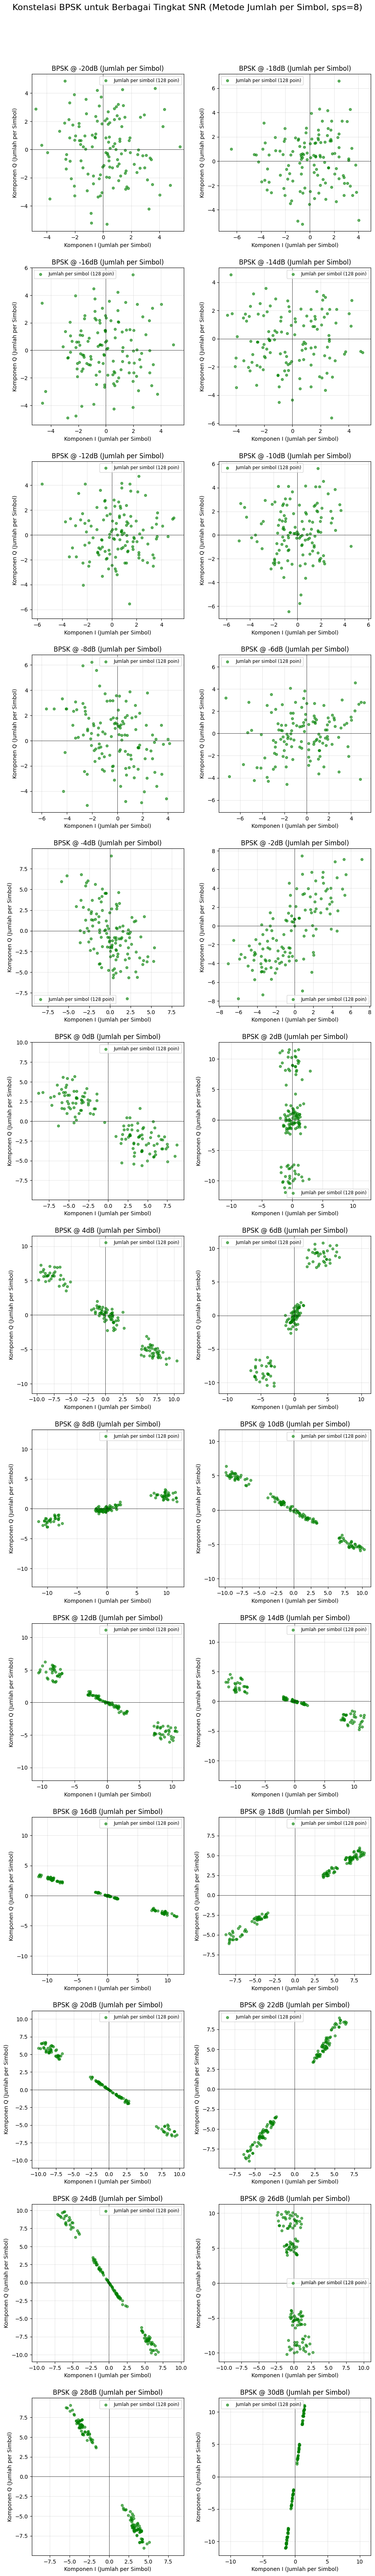


Selesai plotting semua SNR dengan metode jumlah per simbol.


In [24]:
# --- Parameters for selecting THE ONE FRAME ---
if 'my_wsl_file_path_dataset' not in locals():
    # my_wsl_file_path_dataset = 'RadioML2018.01A.h5' # Ganti dengan path file Anda
    raise ValueError("my_wsl_file_path_dataset tidak terdefinisi. Harap atur path ke dataset HDF5 Anda.")

modulation_to_select = 'BPSK'
true_sps = 8

# --- Helper function placeholder ---
def find_modulation_snr_indices(mod, snr, classes_list, y_labels_array, z_snr_array):
    mod_target_str = mod
    mod_match_flags = np.zeros(len(y_labels_array), dtype=bool)
    for i, label_from_y in enumerate(y_labels_array):
        current_label_str = label_from_y.decode('utf-8') if isinstance(label_from_y, bytes) else str(label_from_y)
        if current_label_str == mod_target_str:
            mod_match_flags[i] = True
    mod_indices = np.where(mod_match_flags)[0]
    snr_match_indices = np.where(z_snr_array == snr)[0]
    common_indices = np.intersect1d(mod_indices, snr_match_indices)
    return common_indices.tolist()

# --- Function to calculate constellation points by summing samples per symbol ---
def calculate_symbol_constellation_points_sum(I_frame_data, Q_frame_data, sps_val):
    """
    Menghitung titik konstelasi dengan menjumlahkan sampel I dan Q per simbol.
    Ini sesuai dengan integral r(t)phi(t)dt jika phi(t) adalah pulsa rektangular bernilai 1.
    
    Args:
        I_frame_data (np.array): Sampel komponen I untuk seluruh frame.
        Q_frame_data (np.array): Sampel komponen Q untuk seluruh frame.
        sps_val (int): Sampel per simbol.
    Returns:
        tuple: (I_constellation, Q_constellation) - titik konstelasi
    """
    min_length = min(len(I_frame_data), len(Q_frame_data))
    if min_length < sps_val:
        return np.array([]), np.array([])
        
    if min_length % sps_val != 0:
        num_total_samples_frame = (min_length // sps_val) * sps_val
        I_frame_data = I_frame_data[:num_total_samples_frame]
        Q_frame_data = Q_frame_data[:num_total_samples_frame]

    num_symbols_frame = len(I_frame_data) // sps_val
    if num_symbols_frame == 0:
        return np.array([]), np.array([])
        
    I_reshaped = I_frame_data.reshape(num_symbols_frame, sps_val)
    Q_reshaped = Q_frame_data.reshape(num_symbols_frame, sps_val)
    
    # Hitung jumlah I dan Q per simbol
    I_constellation = np.sum(I_reshaped, axis=1)
    Q_constellation = np.sum(Q_reshaped, axis=1)
    
    return I_constellation, Q_constellation

# --- Load Labels and SNRs ---
try:
    with h5py.File(my_wsl_file_path_dataset, 'r', locking=False) as f:
        if 'Y' in f and 'Z' in f:
            Y_arr_raw = f['Y'][:]
            Z_arr = f['Z'][:, 0]
            
            if 'fixed_classes' not in globals() or fixed_classes is None:
                fixed_classes = ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', 
                                 '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', 
                                 '128QAM', '256QAM', 'AM-DSB-WC', 'AM-DSB-SC', 'AM-SSB-WC', 
                                 'AM-SSB-SC', 'FM', 'GMSK', 'OQPSK']

            if Y_arr_raw.ndim == 2:
                Y_arr_int_labels = np.argmax(Y_arr_raw, axis=1)
                Y_arr = np.array([fixed_classes[i] for i in Y_arr_int_labels])
            else:
                Y_arr = np.array([label.decode('utf-8') if isinstance(label, bytes) else str(label) for label in Y_arr_raw])
            
            if 'fixed_classes' not in globals() or fixed_classes is None:
                 fixed_classes = np.unique(Y_arr).tolist()
        else:
            raise KeyError("Dataset Y atau Z tidak ditemukan dalam file HDF5.")
except Exception as e:
    print(f"Error saat memuat atau memproses Y/Z dari HDF5: {e}.")
    if 'Y_arr' not in locals(): Y_arr = np.array(['BPSK'] * 26)
    if 'Z_arr' not in locals(): Z_arr = np.array([-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])
    if 'fixed_classes' not in locals(): fixed_classes = ['BPSK']

all_snr_levels = np.sort(np.unique(Z_arr))
print(f"Level SNR yang tersedia di dataset (dB): {all_snr_levels}")

num_snrs = len(all_snr_levels)
if num_snrs == 0:
    print("Tidak ada level SNR yang ditemukan dalam dataset. Tidak ada yang bisa diplot.")
    exit()

cols = 2 
rows = math.ceil(num_snrs / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

print(f"\n--- Memulai Plotting Konstelasi BPSK untuk Semua SNR (Metode Jumlah per Simbol, sps={true_sps}) ---")

for i, snr_to_select in enumerate(all_snr_levels):
    ax = axes[i]
    
    idxs = find_modulation_snr_indices(modulation_to_select, snr_to_select, fixed_classes, Y_arr, Z_arr)
    
    if not idxs:
        ax.text(0.5, 0.5, f"Tidak ada data untuk\n{modulation_to_select} @ {snr_to_select}dB", 
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(f"{modulation_to_select} @ {snr_to_select}dB")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    sample_idx_to_load = idxs[0]

    try:
        with h5py.File(my_wsl_file_path_dataset, 'r', locking=False) as f:
            X_ds = f['X']
            one_frame_iq = X_ds[sample_idx_to_load, :, :]
    except Exception as e:
        print(f"Error saat memuat data I/Q untuk indeks {sample_idx_to_load} ({snr_to_select}dB): {e}")
        ax.text(0.5, 0.5, f"Error memuat data\nuntuk {snr_to_select}dB", 
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(f"{modulation_to_select} @ {snr_to_select}dB")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    I_full_frame = one_frame_iq[:, 0]
    Q_full_frame = one_frame_iq[:, 1]

    # --- Hitung titik konstelasi menggunakan metode jumlah per simbol ---
    I_const, Q_const = calculate_symbol_constellation_points_sum(I_full_frame, Q_full_frame, true_sps)

    if len(I_const) > 0:
        ax.scatter(I_const, Q_const, s=20, alpha=0.6, c='green', label=f'Jumlah per simbol ({len(I_const)} poin)')
        ax.set_title(f"{modulation_to_select} @ {snr_to_select}dB (Jumlah per Simbol)")
    else:
        ax.text(0.5, 0.5, "Tidak ada poin konstelasi\nuntuk diplot (Jumlah).", 
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(f"{modulation_to_select} @ {snr_to_select}dB (No Points)")

    ax.set_xlabel("Komponen I (Jumlah per Simbol)")
    ax.set_ylabel("Komponen Q (Jumlah per Simbol)")
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    if len(I_const) > 0: ax.legend(fontsize='small')

for j in range(i + 1, len(axes)): # Mulai dari i+1, bukan num_snrs
    fig.delaxes(axes[j]) 

plt.tight_layout(pad=2.0)
plt.suptitle(f"Konstelasi {modulation_to_select} untuk Berbagai Tingkat SNR (Metode Jumlah per Simbol, sps={true_sps})", fontsize=16, y=1.02)
plt.show()

print("\nSelesai plotting semua SNR dengan metode jumlah per simbol.")

In [ ]:
FILE_PATH = my_wsl_file_path_dataset  # Replace with your actual file path
OUTPUT_DIR = 'signal_records_txt'  # Directory to save the .txt files
SAMPLES_TO_SAVE_PER_MODULATION = 20000

# --- Ensure output directory exists ---
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Created directory: {OUTPUT_DIR}")

# --- Load Metadata (Labels and SNRs) and Process Data ---
try:
    with h5py.File(FILE_PATH, 'r', locking=False) as f:
        if 'Y' not in f or 'Z' not in f or 'X' not in f:
            raise KeyError("X, Y, or Z dataset not found in HDF5 file.")
        
        Y_arr_raw = f['Y'][:]  # Raw labels (e.g., one-hot encoded or byte strings)
        # Z_arr = f['Z'][:, 0]  # SNRs, not directly used for this task but loaded for context
        X_data = f['X']  # Keep reference to X dataset within the context manager

        # Determine fixed_classes (list of unique modulation names as strings)
        if Y_arr_raw.ndim == 2:  # Assuming one-hot encoded
            fixed_classes_list = ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', 
                                  '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', 
                                  '128QAM', '256QAM', 'AM-DSB-WC', 'AM-DSB-SC', 'AM-SSB-WC', 
                                  'AM-SSB-SC', 'FM', 'GMSK', 'OQPSK']
            print("Assuming Y is one-hot encoded and using a predefined fixed_classes_list for RadioML2018.A.")
            if Y_arr_raw.shape[1] != len(fixed_classes_list):
                raise ValueError(f"Mismatch between Y_arr_raw one-hot dimension ({Y_arr_raw.shape[1]}) and fixed_classes_list length ({len(fixed_classes_list)}). Please verify fixed_classes_list.")
            Y_arr_int_labels = np.argmax(Y_arr_raw, axis=1)
            Y_labels_str = np.array([fixed_classes_list[i] for i in Y_arr_int_labels])
        elif Y_arr_raw.dtype.kind in ['S', 'U']:  # String or Unicode
            Y_labels_str = np.array([label.decode('utf-8') if isinstance(label, bytes) else str(label) for label in Y_arr_raw])
            fixed_classes_list = np.unique(Y_labels_str).tolist()
        else:  # Assuming integer labels that need mapping via a predefined fixed_classes_list
            if 'fixed_classes_list' not in locals():
                raise ValueError("Y_arr_raw seems to be integer labels, but fixed_classes_list is not defined.")
            Y_labels_str = np.array([fixed_classes_list[i] for i in Y_arr_raw.flatten()])

        unique_modulations = np.unique(Y_labels_str)
        print(f"Found unique modulations: {unique_modulations}")

        # --- Iterate through each modulation type INSIDE the context manager ---
        for mod_idx, mod_name in enumerate(unique_modulations):
            print(f"\nProcessing modulation: {mod_name} ({mod_idx+1}/{len(unique_modulations)})")
            
            # Find all frame indices for the current modulation type
            current_mod_frame_indices = np.where(Y_labels_str == mod_name)[0]
            
            if len(current_mod_frame_indices) == 0:
                print(f"  No frames found for modulation: {mod_name}. Skipping.")
                continue
                
            # Shuffle the frame indices to get a random assortment of SNRs
            np.random.shuffle(current_mod_frame_indices)
            
            all_i_samples_for_mod = []
            all_q_samples_for_mod = []
            samples_collected = 0
            
            # Iterate through the frames for this modulation until enough samples are collected
            for frame_global_idx in current_mod_frame_indices:
                if samples_collected >= SAMPLES_TO_SAVE_PER_MODULATION:
                    break
                    
                # Access the I/Q data for the current frame from the HDF5 dataset
                # Now X_data is accessible within the same context manager
                frame_iq_data = X_data[frame_global_idx, :, :]  # Loads one frame (1024, 2)
                
                i_samps = frame_iq_data[:, 0]
                q_samps = frame_iq_data[:, 1]
                
                samples_to_take_from_this_frame = min(len(i_samps), SAMPLES_TO_SAVE_PER_MODULATION - samples_collected)
                
                all_i_samples_for_mod.extend(i_samps[:samples_to_take_from_this_frame])
                all_q_samples_for_mod.extend(q_samps[:samples_to_take_from_this_frame])
                samples_collected += samples_to_take_from_this_frame
                
            if samples_collected > 0:
                # Convert to NumPy arrays
                final_i_samples = np.array(all_i_samples_for_mod)
                final_q_samples = np.array(all_q_samples_for_mod)
                
                # Ensure we only save up to SAMPLES_TO_SAVE_PER_MODULATION
                final_i_samples = final_i_samples[:SAMPLES_TO_SAVE_PER_MODULATION]
                final_q_samples = final_q_samples[:SAMPLES_TO_SAVE_PER_MODULATION]

                # Prepare data for saving (stack I and Q as columns)
                output_data = np.vstack((final_i_samples, final_q_samples)).T  # Shape: (SAMPLES_TO_SAVE, 2)
                
                # Define output filename
                # Sanitize mod_name for use in filename (replace special characters)
                safe_mod_name = "".join(c if c.isalnum() else "_" for c in mod_name)
                output_filename = os.path.join(OUTPUT_DIR, f"{safe_mod_name}_signal_record.txt")
                
                # Save to .txt file
                # Using a simple space delimiter. You can choose comma or tab as well.
                np.savetxt(output_filename, output_data, fmt='%.6f', delimiter=' ', header='I Q', comments='')
                print(f"  Saved {len(final_i_samples)} I/Q samples to {output_filename}")
            else:
                print(f"  No samples were collected for {mod_name} (this shouldn't happen if frames were found).")

except Exception as e:
    print(f"Error loading metadata from HDF5 file: {e}")
    print("Please ensure FILE_PATH is correct and the HDF5 file contains X, Y, Z datasets.")
    print("You might need to adjust how Y_labels_str and unique_modulations are derived based on your Y data format.")

print("\nProcessing complete.")

Assuming Y is one-hot encoded and using a predefined fixed_classes_list for RadioML2018.A.
Found unique modulations: ['128APSK' '128QAM' '16APSK' '16PSK' '16QAM' '256QAM' '32APSK' '32PSK'
 '32QAM' '4ASK' '64APSK' '64QAM' '8ASK' '8PSK' 'AM-DSB-SC' 'AM-DSB-WC'
 'AM-SSB-SC' 'AM-SSB-WC' 'BPSK' 'FM' 'GMSK' 'OOK' 'OQPSK' 'QPSK']

Processing modulation: 128APSK (1/24)
  Saved 20000 I/Q samples to signal_records_txt\128APSK_signal_record.txt

Processing modulation: 128QAM (2/24)
  Saved 20000 I/Q samples to signal_records_txt\128QAM_signal_record.txt

Processing modulation: 16APSK (3/24)
  Saved 20000 I/Q samples to signal_records_txt\16APSK_signal_record.txt

Processing modulation: 16PSK (4/24)
  Saved 20000 I/Q samples to signal_records_txt\16PSK_signal_record.txt

Processing modulation: 16QAM (5/24)
  Saved 20000 I/Q samples to signal_records_txt\16QAM_signal_record.txt

Processing modulation: 256QAM (6/24)
  Saved 20000 I/Q samples to signal_records_txt\256QAM_signal_record.txt

Processing

In [ ]:
FILE_PATH = my_wsl_file_path_dataset  # Replace with your actual file path
OUTPUT_DIR = 'telecom_signal_analysis'  # Directory to save analysis results
SAMPLES_TO_ANALYZE_PER_MODULATION = 1000  # Number of frames to analyze per modulation
SAMPLE_RATE = 200000  # Typical sample rate for RadioML datasets (adjust if different)

# --- Ensure output directory exists ---
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Created directory: {OUTPUT_DIR}")

def extract_signal_features(iq_data, sample_rate=SAMPLE_RATE):
    """
    Extract comprehensive telecommunications features from I/Q data
    """
    # Convert to complex signal
    complex_signal = iq_data[:, 0] + 1j * iq_data[:, 1]
    
    features = {}
    
    # === Time Domain Features ===
    # Signal power and statistics
    signal_power = np.mean(np.abs(complex_signal)**2)
    features['signal_power_db'] = 10 * np.log10(signal_power + 1e-12)
    features['peak_power_db'] = 10 * np.log10(np.max(np.abs(complex_signal)**2) + 1e-12)
    features['papr_db'] = features['peak_power_db'] - features['signal_power_db']  # Peak-to-Average Power Ratio
    
    # Amplitude statistics
    amplitude = np.abs(complex_signal)
    features['amplitude_mean'] = np.mean(amplitude)
    features['amplitude_std'] = np.std(amplitude)
    features['amplitude_skewness'] = stats.skew(amplitude)
    features['amplitude_kurtosis'] = stats.kurtosis(amplitude)
    
    # Phase statistics
    phase = np.angle(complex_signal)
    phase_unwrapped = np.unwrap(phase)
    features['phase_variance'] = np.var(phase)
    features['phase_range'] = np.ptp(phase)
    
    # Instantaneous frequency (derivative of unwrapped phase)
    inst_freq = np.diff(phase_unwrapped) * sample_rate / (2 * np.pi)
    features['inst_freq_mean'] = np.mean(inst_freq)
    features['inst_freq_std'] = np.std(inst_freq)
    features['freq_deviation'] = np.max(np.abs(inst_freq))
    
    # === Constellation Features ===
    # EVM (Error Vector Magnitude) approximation
    # Normalize to unit circle for analysis
    normalized_signal = complex_signal / np.sqrt(signal_power)
    features['constellation_radius_std'] = np.std(np.abs(normalized_signal))
    
    # I/Q imbalance
    i_component = np.real(complex_signal)
    q_component = np.imag(complex_signal)
    features['iq_power_ratio_db'] = 10 * np.log10((np.var(i_component) / (np.var(q_component) + 1e-12)) + 1e-12)
    features['iq_correlation'] = np.corrcoef(i_component, q_component)[0, 1]
    
    # === Frequency Domain Features ===
    # FFT analysis
    fft_signal = fft(complex_signal)
    fft_magnitude = np.abs(fft_signal)
    freqs = fftfreq(len(complex_signal), 1/sample_rate)
    
    # Spectral features
    features['spectral_centroid'] = np.sum(freqs[:len(freqs)//2] * fft_magnitude[:len(freqs)//2]) / np.sum(fft_magnitude[:len(freqs)//2])
    features['spectral_bandwidth'] = np.sqrt(np.sum(((freqs[:len(freqs)//2] - features['spectral_centroid'])**2) * fft_magnitude[:len(freqs)//2]) / np.sum(fft_magnitude[:len(freqs)//2]))
    features['spectral_rolloff'] = freqs[np.where(np.cumsum(fft_magnitude[:len(freqs)//2]) >= 0.95 * np.sum(fft_magnitude[:len(freqs)//2]))[0][0]]
    
    # Occupied bandwidth (99% power bandwidth)
    power_spectrum = fft_magnitude**2
    total_power = np.sum(power_spectrum[:len(freqs)//2])
    cumulative_power = np.cumsum(power_spectrum[:len(freqs)//2])
    bw_low = freqs[np.where(cumulative_power >= 0.005 * total_power)[0][0]]
    bw_high = freqs[np.where(cumulative_power >= 0.995 * total_power)[0][0]]
    features['occupied_bandwidth'] = bw_high - bw_low
    
    # === Higher Order Statistics ===
    # Cumulants (useful for modulation classification)
    features['c20'] = np.mean(complex_signal**2)  # 2nd order cumulant
    features['c21'] = np.mean(np.abs(complex_signal)**2)  # 2nd order moment
    features['c40'] = np.mean(complex_signal**4) - 3*(np.mean(complex_signal**2))**2  # 4th order cumulant
    features['c42'] = np.mean(np.abs(complex_signal)**4) - np.abs(np.mean(complex_signal**2))**2 - 2*(np.mean(np.abs(complex_signal)**2))**2
    
    # === Cyclostationary Features ===
    # Spectral correlation (simplified)
    autocorr = np.correlate(complex_signal, complex_signal, mode='full')
    autocorr = autocorr[len(autocorr)//2:]
    features['autocorr_peak_ratio'] = np.max(np.abs(autocorr[1:10])) / np.abs(autocorr[0]) if len(autocorr) > 10 else 0
    
    return features

Created directory: telecom_signal_analysis


In [ ]:
def analyze_modulation_type(mod_name, X_data, Y_labels_str, Z_arr=None):
    """
    Comprehensive analysis of a specific modulation type
    """
    print(f"\nAnalyzing modulation: {mod_name}")
    
    # Find all frame indices for the current modulation type
    current_mod_frame_indices = np.where(Y_labels_str == mod_name)[0]
    
    if len(current_mod_frame_indices) == 0:
        print(f"  No frames found for modulation: {mod_name}")
        return None
    
    # Limit number of samples to analyze for performance
    if len(current_mod_frame_indices) > SAMPLES_TO_ANALYZE_PER_MODULATION:
        selected_indices = np.random.choice(current_mod_frame_indices, 
                                          SAMPLES_TO_ANALYZE_PER_MODULATION, 
                                          replace=False)
    else:
        selected_indices = current_mod_frame_indices
    
    all_features = []
    snr_values = []
    
    for idx in selected_indices:
        # Load I/Q data
        frame_iq_data = X_data[idx, :, :]
        
        # Extract features
        features = extract_signal_features(frame_iq_data)
        features['frame_index'] = idx
        features['modulation'] = mod_name
        
        # Add SNR if available
        if Z_arr is not None:
            snr = Z_arr[idx]
            features['snr_db'] = snr
            snr_values.append(snr)
        
        all_features.append(features)
    
    # Convert to DataFrame for analysis
    df = pd.DataFrame(all_features)
    
    # Generate summary statistics
    summary = {
        'modulation_type': mod_name,
        'total_samples': len(current_mod_frame_indices),
        'analyzed_samples': len(selected_indices),
        'feature_statistics': {}
    }
    
    if Z_arr is not None:
        summary['snr_range'] = {
            'min': float(np.min(snr_values)),
            'max': float(np.max(snr_values)),
            'mean': float(np.mean(snr_values))
        }
    
    # Calculate feature statistics
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    for col in numeric_columns:
        if col not in ['frame_index', 'snr_db']:
            summary['feature_statistics'][col] = {
                'mean': float(df[col].mean()),
                'std': float(df[col].std()),
                'min': float(df[col].min()),
                'max': float(df[col].max())
            }
    
    return df, summary


In [ ]:
try:
    with h5py.File(FILE_PATH, 'r', locking=False) as f:
        if 'Y' not in f or 'X' not in f:
            raise KeyError("X or Y dataset not found in HDF5 file.")
        
        Y_arr_raw = f['Y'][:]
        X_data = f['X']
        Z_arr = f['Z'][:, 0] if 'Z' in f else None  # SNR values
        
        # Process labels
        if Y_arr_raw.ndim == 2:  # One-hot encoded
            fixed_classes_list = ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', 
                                  '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', 
                                  '128QAM', '256QAM', 'AM-DSB-WC', 'AM-DSB-SC', 'AM-SSB-WC', 
                                  'AM-SSB-SC', 'FM', 'GMSK', 'OQPSK']
            Y_arr_int_labels = np.argmax(Y_arr_raw, axis=1)
            Y_labels_str = np.array([fixed_classes_list[i] for i in Y_arr_int_labels])
        elif Y_arr_raw.dtype.kind in ['S', 'U']:
            Y_labels_str = np.array([label.decode('utf-8') if isinstance(label, bytes) else str(label) for label in Y_arr_raw])
        else:
            raise ValueError("Unsupported label format")
        
        unique_modulations = np.unique(Y_labels_str)
        print(f"Found unique modulations: {unique_modulations}")
        
        # Analysis results storage
        all_features_df = []
        all_summaries = {}
        
        # Process each modulation type
        for mod_name in unique_modulations:
            result = analyze_modulation_type(mod_name, X_data, Y_labels_str, Z_arr)
            
            if result is not None:
                features_df, summary = result
                all_features_df.append(features_df)
                all_summaries[mod_name] = summary
                
                print(f"  Analyzed {len(features_df)} samples")
                print(f"  Avg Signal Power: {summary['feature_statistics']['signal_power_db']['mean']:.2f} dB")
                if 'snr_range' in summary:
                    print(f"  SNR Range: {summary['snr_range']['min']:.1f} to {summary['snr_range']['max']:.1f} dB")
        
        # Combine all features
        if all_features_df:
            combined_features = pd.concat(all_features_df, ignore_index=True)
            
            # Save detailed features
            features_file = os.path.join(OUTPUT_DIR, 'detailed_signal_features.csv')
            combined_features.to_csv(features_file, index=False)
            print(f"\nSaved detailed features to: {features_file}")
            
            # Save summary statistics
            summary_file = os.path.join(OUTPUT_DIR, 'modulation_analysis_summary.json')
            with open(summary_file, 'w') as f:
                json.dump(all_summaries, f, indent=2)
            print(f"Saved analysis summary to: {summary_file}")
            
            # Create modulation comparison
            comparison_stats = []
            for mod_name in unique_modulations:
                if mod_name in all_summaries:
                    mod_data = combined_features[combined_features['modulation'] == mod_name]
                    if len(mod_data) > 0:
                        stats_row = {
                            'modulation': mod_name,
                            'samples': len(mod_data),
                            'avg_signal_power_db': mod_data['signal_power_db'].mean(),
                            'avg_papr_db': mod_data['papr_db'].mean(),
                            'avg_occupied_bandwidth': mod_data['occupied_bandwidth'].mean(),
                            'constellation_stability': 1.0 / (mod_data['constellation_radius_std'].mean() + 1e-6)
                        }
                        if 'snr_db' in mod_data.columns:
                            stats_row['avg_snr_db'] = mod_data['snr_db'].mean()
                        comparison_stats.append(stats_row)
            
            comparison_df = pd.DataFrame(comparison_stats)
            comparison_file = os.path.join(OUTPUT_DIR, 'modulation_comparison.csv')
            comparison_df.to_csv(comparison_file, index=False)
            print(f"Saved modulation comparison to: {comparison_file}")
            
            print(f"\n=== ANALYSIS COMPLETE ===")
            print(f"Total modulations analyzed: {len(unique_modulations)}")
            print(f"Total samples processed: {len(combined_features)}")
            print(f"Features extracted per sample: {len(combined_features.columns) - 3}")  # Excluding metadata columns

except Exception as e:
    print(f"Error during analysis: {e}")
    import traceback
    traceback.print_exc()

print("\nTelecommunications signal analysis complete!")

Found unique modulations: ['128APSK' '128QAM' '16APSK' '16PSK' '16QAM' '256QAM' '32APSK' '32PSK'
 '32QAM' '4ASK' '64APSK' '64QAM' '8ASK' '8PSK' 'AM-DSB-SC' 'AM-DSB-WC'
 'AM-SSB-SC' 'AM-SSB-WC' 'BPSK' 'FM' 'GMSK' 'OOK' 'OQPSK' 'QPSK']

Analyzing modulation: 128APSK


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21620\2829428571.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  'mean': float(df[col].mean()),
c:\Users\ASUS\.conda\envs\dl-env\Lib\site-packages\numpy\_core\_methods.py:52: ComplexWarning: Casting complex values to real discards the imaginary part
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\ASUS\.conda\envs\dl-env\Lib\site-packages\pandas\core\nanops.py:950: RuntimeWarning: invalid value encountered in sqrt
  result = np.sqrt(nanvar(values, axis=axis, skipna=skipna, ddof=ddof, mask=mask))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21620\2829428571.py:67: ComplexWarning: Casting complex values to real discards the imaginary part
  'min': float(df[col].min()),
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21620\2829428571.py:68: ComplexWarning: Casting complex values to real discards the imaginary part
  'max': float(df[col].max())


  Analyzed 1000 samples
  Avg Signal Power: 0.01 dB
  SNR Range: -20.0 to 30.0 dB

Analyzing modulation: 128QAM
  Analyzed 1000 samples
  Avg Signal Power: 0.01 dB
  SNR Range: -20.0 to 30.0 dB

Analyzing modulation: 16APSK
  Analyzed 1000 samples
  Avg Signal Power: 0.01 dB
  SNR Range: -20.0 to 30.0 dB

Analyzing modulation: 16PSK
  Analyzed 1000 samples
  Avg Signal Power: 0.01 dB
  SNR Range: -20.0 to 30.0 dB

Analyzing modulation: 16QAM
  Analyzed 1000 samples
  Avg Signal Power: 0.02 dB
  SNR Range: -20.0 to 30.0 dB

Analyzing modulation: 256QAM
  Analyzed 1000 samples
  Avg Signal Power: 0.00 dB
  SNR Range: -20.0 to 30.0 dB

Analyzing modulation: 32APSK
  Analyzed 1000 samples
  Avg Signal Power: 0.01 dB
  SNR Range: -20.0 to 30.0 dB

Analyzing modulation: 32PSK
  Analyzed 1000 samples
  Avg Signal Power: 0.01 dB
  SNR Range: -20.0 to 30.0 dB

Analyzing modulation: 32QAM
  Analyzed 1000 samples
  Avg Signal Power: 0.02 dB
  SNR Range: -20.0 to 30.0 dB

Analyzing modulation: 4AS